Raw-Factor EDA

### Step 1 — Factor EDA: leading vs coincident

S0 — Load & assemble the raw panel

In [97]:
# %% S0 — setup + assemble raw factor panel (FRED parquet + DuckDB), no transforms
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, duckdb
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError(f"repo root not found above {p}")

ROOT = _repo_root()

while not (ROOT / "data" / "market_data.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DB = str(ROOT / "data" / "market_data.duckdb")
PANEL = ROOT / "scratch" / "raw_factor_panel.parquet"   # from scratch_source_factors.py
con = duckdb.connect(DB, read_only=True)                # read_only: never lock the DB

# --- FRED-sourced factors (scratch parquet, long format date/symbol/value) ---
fred = pd.read_parquet(PANEL)
fred["date"] = pd.to_datetime(fred["date"])
fred = fred.pivot(index="date", columns="symbol", values="value")
# columns: real_yield_10y, dxy_broad, dxy_major_legacy, bondvol_vxtyn_legacy

# --- DB-resident factors (macro_data long; price_data for ETFs) ---
macro = con.execute("""
    SELECT date, symbol, close FROM macro_data
    WHERE symbol IN ('VIX','BAMLH0A0HYM2','DGS10','DGS2')
""").df()
macro["date"] = pd.to_datetime(macro["date"])
macro = macro.pivot(index="date", columns="symbol", values="close").rename(
    columns={"BAMLH0A0HYM2": "hy_spread"})

etf = con.execute("""
    SELECT date, ticker, close FROM price_data WHERE ticker IN ('HYG','LQD','MOVE')
""").df()
etf["date"] = pd.to_datetime(etf["date"])
etf = etf.pivot(index="date", columns="ticker", values="close")

# --- market benchmark for S3 (raw close -> daily return) ---
mkt = con.execute("""
    SELECT date, close FROM price_data WHERE ticker = 'QQQ' ORDER BY date
""").df()
mkt["date"] = pd.to_datetime(mkt["date"])
mkt = mkt.set_index("date")["close"]
mkt_ret = mkt.pct_change().rename("qqq_ret")

# --- merge everything on a daily index (NO ffill yet -- S0 shows true coverage) ---
panel = fred.join(macro, how="outer").join(etf, how="outer").sort_index()

# derived factors (per the 'both legs + derived' decision)
panel["term_spread"]  = panel["DGS10"] - panel["DGS2"]      # 2s10s
panel["credit_ratio"] = panel["HYG"] / panel["LQD"]          # risk-appetite proxy

FACTORS = [
    "VIX", "hy_spread", "real_yield_10y",
    "dxy_broad", "dxy_major_legacy",
    "MOVE", "bondvol_vxtyn_legacy",
    "DGS10", "DGS2", "term_spread",
    "HYG", "LQD", "credit_ratio",
]

# coverage table -- the cliffs matter (1990 core -> 2003 credit/RY -> 2006 DXY -> 2021 MOVE)
cov = pd.DataFrame({
    "n":     panel[FACTORS].notna().sum(),
    "start": panel[FACTORS].apply(lambda s: s.first_valid_index()),
    "end":   panel[FACTORS].apply(lambda s: s.last_valid_index()),
})
print(cov.to_string())
print(f"\npanel: {panel.index.min().date()} -> {panel.index.max().date()}  rows={len(panel)}")

                         n      start        end
VIX                   9215 1990-01-02 2026-06-24
hy_spread             6134 2003-01-02 2026-06-24
real_yield_10y        5871 2003-01-02 2026-06-22
dxy_broad             5130 2006-01-02 2026-06-18
dxy_major_legacy      7596 1990-01-02 2019-12-31
MOVE                  1321 2021-03-23 2026-06-25
bondvol_vxtyn_legacy  4363 2003-01-02 2020-05-15
DGS10                 9125 1990-01-02 2026-06-24
DGS2                  9125 1990-01-02 2026-06-24
term_spread           9125 1990-01-02 2026-06-24
HYG                   4833 2007-04-11 2026-06-25
LQD                   6015 2002-07-30 2026-06-25
credit_ratio          4833 2007-04-11 2026-06-25

panel: 1990-01-02 -> 2026-06-25  rows=9504


                         n     mean   median      std   skew  kurtosis     p01      p99  jb_p
factor                                                                                       
VIX                   9215   19.449   17.610    7.739  2.208     8.735  10.160   46.717   0.0
hy_spread             6134    5.000    4.250    2.547  3.092    12.519   2.640   17.050   0.0
real_yield_10y        5871    0.992    1.030    1.005 -0.319    -0.945  -1.040    2.656   0.0
dxy_broad             5130  106.289  109.992   12.335 -0.066    -1.468  86.449  127.731   0.0
dxy_major_legacy      7596   87.511   87.756    9.658  0.217    -0.332  69.623  110.578   0.0
MOVE                  1321  218.931  133.950  231.335  1.112     0.293   5.660  843.000   0.0
bondvol_vxtyn_legacy  4363    6.199    5.590    2.064  1.269     1.645   3.550   12.984   0.0
DGS10                 9125    4.252    4.180    1.927  0.323    -0.635   0.690    8.640   0.0
DGS2                  9125    3.250    3.460    2.256  0.219

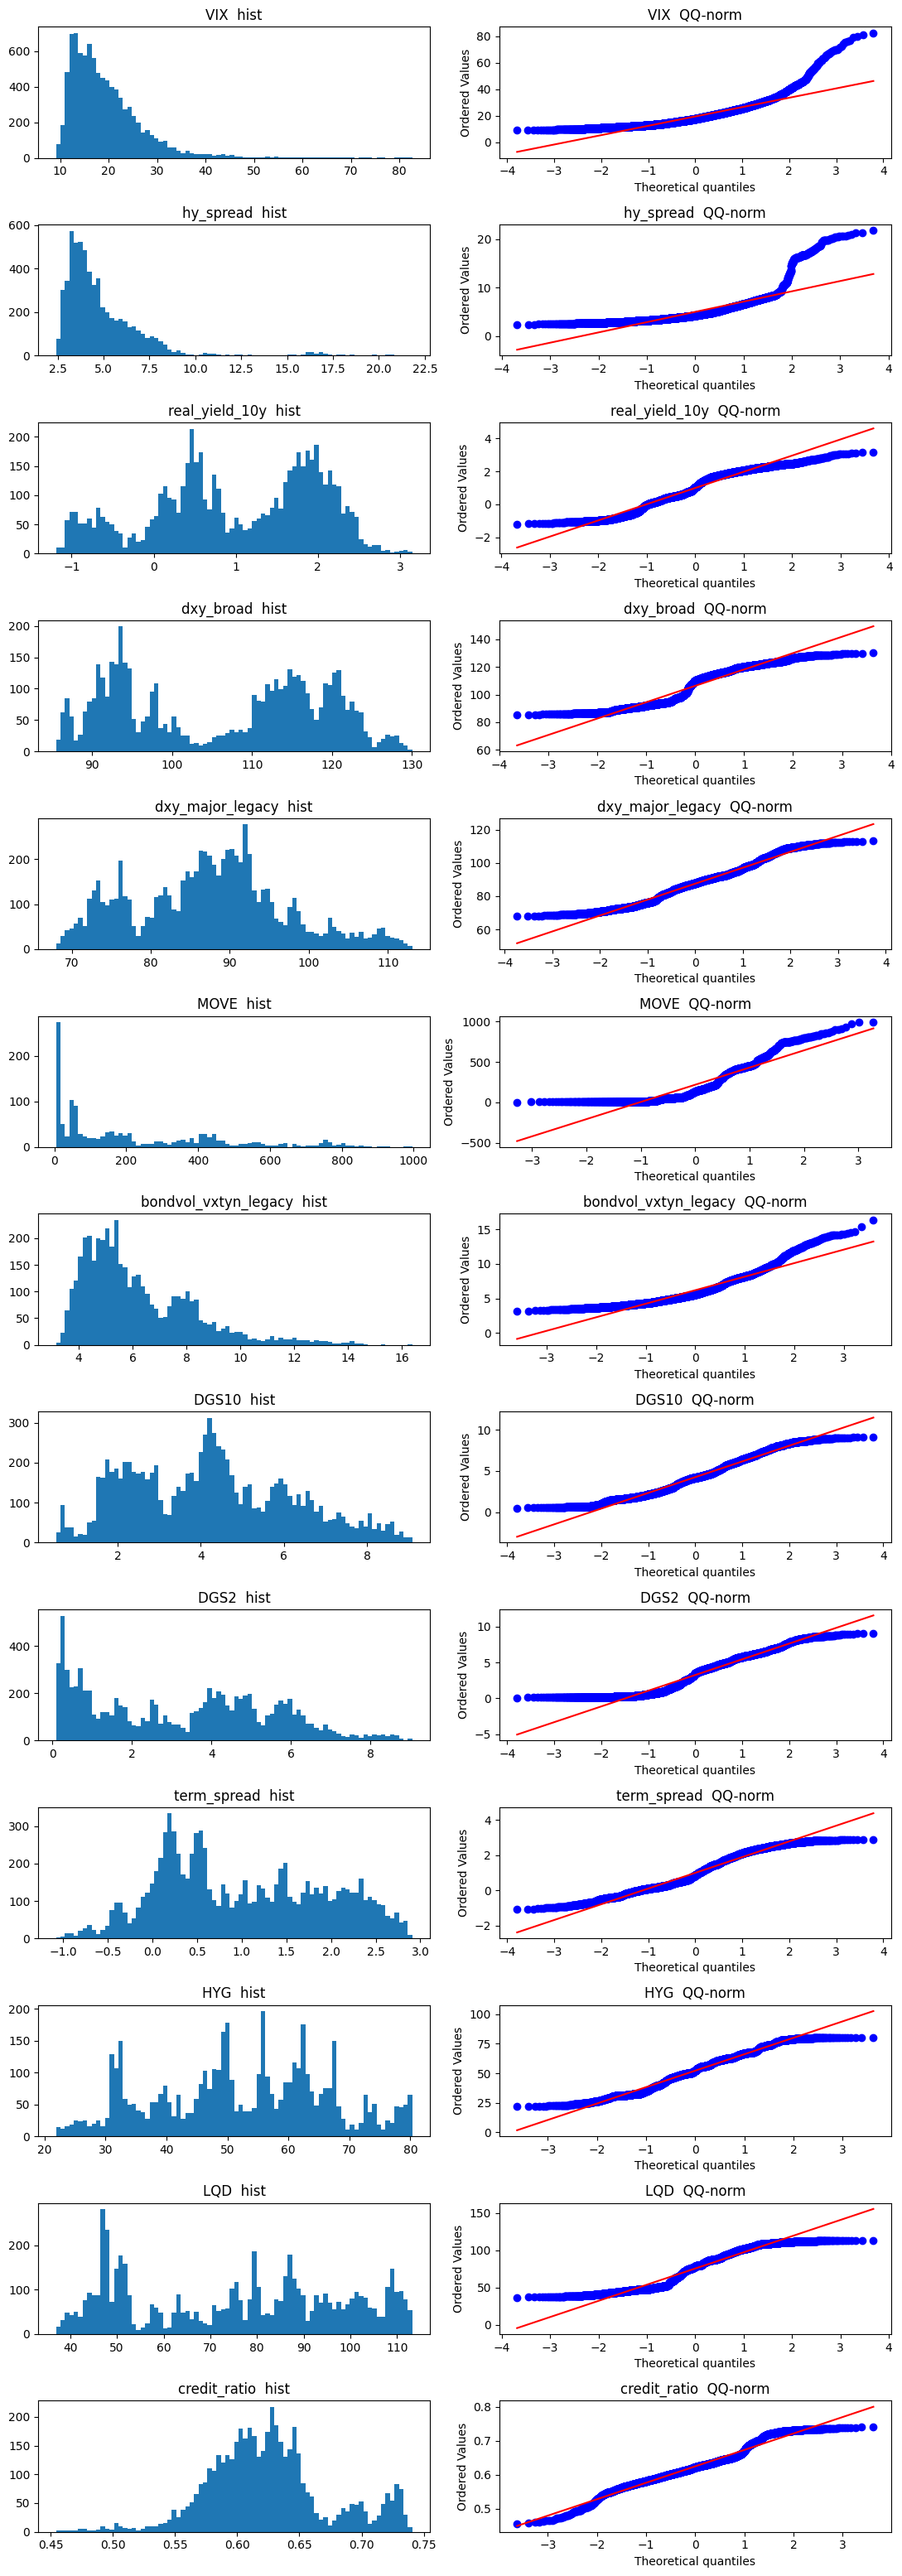

In [98]:
# %% S1 — moments + fat-tail diagnostics on RAW levels
from scipy import stats

rows = []
for f in FACTORS:
    s = panel[f].dropna()
    rows.append({
        "factor": f, "n": len(s),
        "mean": s.mean(), "median": s.median(), "std": s.std(),
        "skew": stats.skew(s), "kurtosis": stats.kurtosis(s),  # excess (0 = normal)
        "p01": s.quantile(.01), "p99": s.quantile(.99),
        "jb_p": stats.jarque_bera(s).pvalue,                   # <0.05 => non-normal
    })
moments = pd.DataFrame(rows).set_index("factor")
print(moments.round(3).to_string())

# histograms + QQ vs normal, one row per factor
n = len(FACTORS)
fig, ax = plt.subplots(n, 2, figsize=(11, 2.4 * n))
for i, f in enumerate(FACTORS):
    s = panel[f].dropna()
    ax[i, 0].hist(s, bins=80); ax[i, 0].set_title(f"{f}  hist")
    stats.probplot(s, dist="norm", plot=ax[i, 1]); ax[i, 1].set_title(f"{f}  QQ-norm")
fig.tight_layout()

                      adf_p  kpss_p  acf_21  acf_252  ar1_halflife_d           label
factor                                                                              
VIX                   0.000    0.10   0.762    0.248          29.629  mean-reverting
hy_spread             0.033    0.01   0.949    0.305         749.415  mean-reverting
real_yield_10y        0.448    0.01   0.970    0.699         512.085        drifting
dxy_broad             0.790    0.01   0.987    0.836        2128.392        drifting
dxy_major_legacy      0.429    0.01   0.984    0.801         924.134        drifting
MOVE                  0.009    0.01   0.912    0.369         115.305  mean-reverting
bondvol_vxtyn_legacy  0.002    0.01   0.838    0.328          45.350  mean-reverting
DGS10                 0.202    0.01   0.986    0.826        1062.438        drifting
DGS2                  0.172    0.01   0.988    0.775        1306.738        drifting
term_spread           0.248    0.01   0.981    0.650         805.

Text(0, 0.5, 'rolling 1y mean, z-scaled')

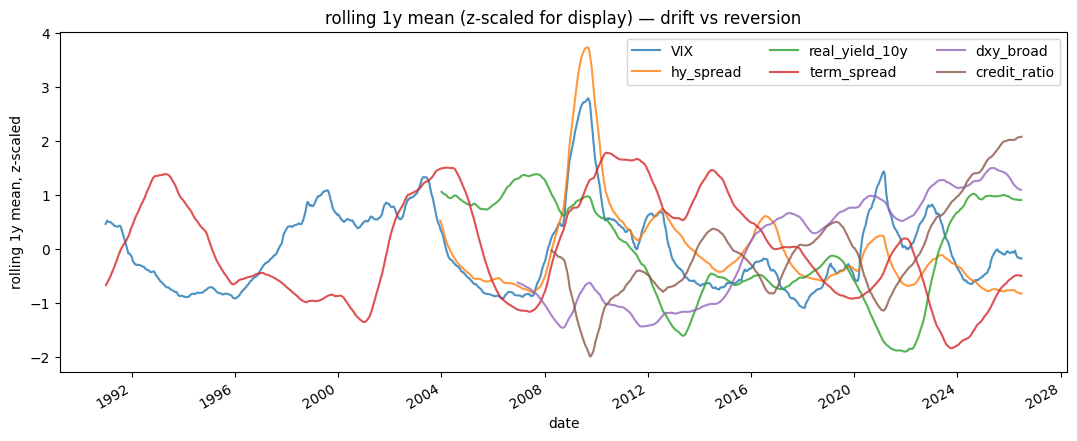

In [99]:
# %% S2 — ADF/KPSS + ACF + rolling mean.  This sets the per-factor LOOKBACK decision.
from statsmodels.tsa.stattools import adfuller, kpss, acf

rows = []
for f in FACTORS:
    s = panel[f].dropna()
    adf_p  = adfuller(s, autolag="AIC")[1]
    try:
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = np.nan
    ac = acf(s, nlags=252, fft=True)
    # half-life of mean reversion via AR(1): dx = a + b*x_{t-1}; HL = -ln2 / ln(1+b)
    x = s.shift(1).dropna(); y = s.loc[x.index]
    b = np.polyfit(x, y, 1)[0] - 1.0
    hl = (-np.log(2) / np.log(1 + b)) if -1 < b < 0 else np.nan
    rows.append({
        "factor": f,
        "adf_p": adf_p,            # <0.05 => stationary (reject unit root)
        "kpss_p": kpss_p,          # <0.05 => NON-stationary (reject level-stationarity)
        "acf_21": ac[21], "acf_252": ac[252],
        "ar1_halflife_d": hl,
        "label": ("mean-reverting" if adf_p < 0.05 else "drifting"),
    })
stat = pd.DataFrame(rows).set_index("factor")
print(stat.round(3).to_string())

# rolling 1y mean -- visual of secular drift (P3) vs mean-reversion
# BUGFIX: panel has an OUTER-joined index with NaN holes (S0 intentionally skips ffill).
# rolling(252) counts INDEX ROWS, so any 252-row window touching a NaN returns NaN -> the line
# shatters into fragments. Fix at source: dropna() PER FACTOR so each rolls over its own valid obs.
fig, ax = plt.subplots(figsize=(13, 5))
for f in ["VIX", "hy_spread", "real_yield_10y", "term_spread", "dxy_broad", "credit_ratio"]:
    s = panel[f].dropna()                                 # <-- per-factor, contiguous valid series
    z = (s - s.mean()) / s.std()                          # z only for shared-axis VISUAL
    z.rolling(252).mean().plot(ax=ax, label=f, alpha=.8)
ax.legend(ncol=3); ax.set_title("rolling 1y mean (z-scaled for display) — drift vs reversion")
ax.set_ylabel("rolling 1y mean, z-scaled")

In [100]:
# %% S2b — full-history ADF is UNRELIABLE on regime-switching factors (real_yield is bimodal!).
#          Test stationarity WITHIN a rolling window: is the factor mean-reverting locally even if
#          it drifts globally? That distinction IS the §10 reason-#1 decision (rolling window vs.
#          differencing). A factor MR-within-5yr but drifting-across-20yr => use a rolling lookback.
def rolling_adf_pass_rate(s, win=1260, step=63):   # 5yr window, quarterly step
    s = s.dropna(); ps = []
    for i in range(0, len(s) - win, step):
        seg = s.iloc[i:i + win]
        try: ps.append(adfuller(seg, autolag="AIC")[1])
        except Exception: pass
    ps = np.array(ps)
    return (ps < 0.05).mean() if len(ps) else np.nan, len(ps)

for f in ["real_yield_10y", "DGS10", "term_spread", "dxy_broad", "VIX", "hy_spread"]:
    rate, k = rolling_adf_pass_rate(panel[f])
    full = adfuller(panel[f].dropna(), autolag="AIC")[1]
    print(f"{f:16s} full-ADF p={full:.3f} ({'MR' if full<.05 else 'drift'})  "
          f"| rolling-5yr MR-rate={rate:.2f} over {k} windows")

real_yield_10y   full-ADF p=0.448 (drift)  | rolling-5yr MR-rate=0.04 over 74 windows
DGS10            full-ADF p=0.202 (drift)  | rolling-5yr MR-rate=0.00 over 125 windows
term_spread      full-ADF p=0.248 (drift)  | rolling-5yr MR-rate=0.02 over 125 windows
dxy_broad        full-ADF p=0.790 (drift)  | rolling-5yr MR-rate=0.05 over 62 windows
VIX              full-ADF p=0.000 (MR)  | rolling-5yr MR-rate=0.57 over 127 windows
hy_spread        full-ADF p=0.033 (MR)  | rolling-5yr MR-rate=0.17 over 78 windows


                      all_median  tail_median  all_p95  tail_pctl_of_all  tail_vs_all_z
factor                                                                                 
VIX                       18.050       27.020   34.020             0.860          1.317
hy_spread                  4.260        5.790    8.458             0.755          0.955
real_yield_10y             1.020        1.250    2.360             0.532          0.070
dxy_broad                110.117      112.774  123.404             0.587          0.214
dxy_major_legacy          85.920      101.161  107.496             0.879          0.940
MOVE                     133.950      314.250  744.750             0.697          0.106
bondvol_vxtyn_legacy       5.590        8.040   10.146             0.821          1.246
DGS10                      3.550        4.290    5.740             0.716          0.529
DGS2                       1.960        2.970    5.630             0.629          0.430
term_spread                0.960

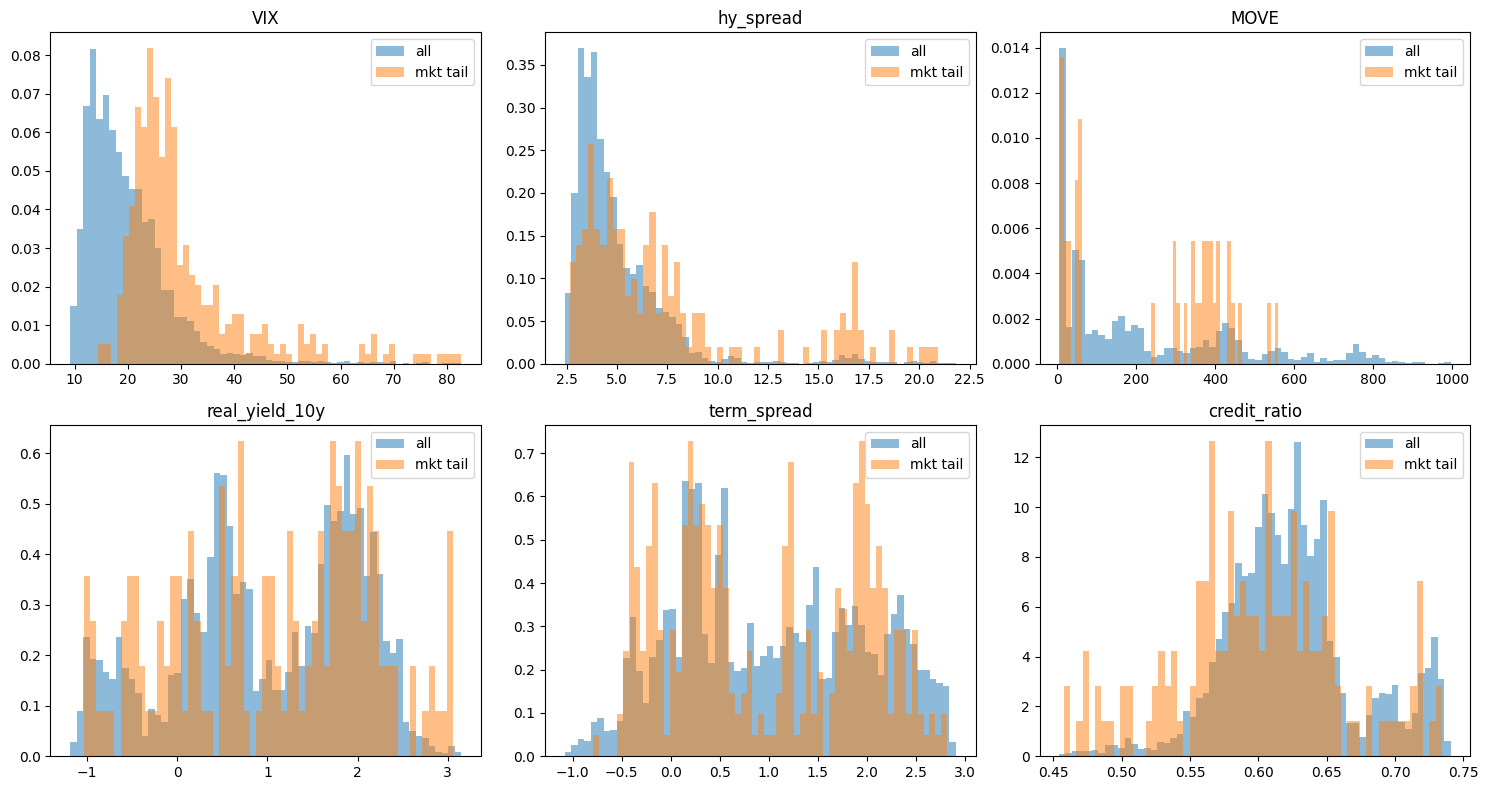

In [101]:
# %% S3 — what level does each raw factor sit at when the MARKET is in its tail?
#         NOT lead-lag (that's §A2, closed). Pure same-day conditional LEVELS, full history.
df3 = panel.join(mkt_ret, how="inner")
tail = df3["qqq_ret"] <= df3["qqq_ret"].quantile(0.05)    # worst 5% market days, full horizon

rows = []
for f in FACTORS:
    s_all  = df3[f].dropna()
    s_tail = df3.loc[tail, f].dropna()
    if len(s_tail) < 30:
        continue
    rows.append({
        "factor": f,
        "all_median":  s_all.median(),
        "tail_median": s_tail.median(),
        "all_p95":     s_all.quantile(.95),
        "tail_pctl_of_all": (s_all < s_tail.median()).mean(),  # where tail-median sits in full dist
        "tail_vs_all_z": (s_tail.mean() - s_all.mean()) / s_all.std(),
    })
stress = pd.DataFrame(rows).set_index("factor")
print(stress.round(3).to_string())

# distribution overlap: full vs tail-day, per factor
keyf = ["VIX", "hy_spread", "MOVE", "real_yield_10y", "term_spread", "credit_ratio"]
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for a, f in zip(ax.ravel(), keyf):
    a.hist(df3[f].dropna(), bins=60, density=True, alpha=.5, label="all")
    a.hist(df3.loc[tail, f].dropna(), bins=60, density=True, alpha=.5, label="mkt tail")
    a.set_title(f); a.legend()
fig.tight_layout()

                      t-21  t-10   t-5   t-3   t-1   t+0  lead_t-21
factor                                                             
VIX                   0.62  0.78  0.87  0.95  0.95  1.32       0.62
hy_spread             0.61  0.72  0.79  0.84  0.89  0.95       0.61
real_yield_10y       -0.00  0.05  0.07  0.08  0.07  0.07      -0.00
dxy_broad             0.12  0.15  0.16  0.18  0.19  0.21       0.12
dxy_major_legacy      0.91  0.92  0.92  0.93  0.93  0.94       0.91
MOVE                  0.21  0.15  0.13  0.13  0.14  0.11       0.21
bondvol_vxtyn_legacy  0.68  0.96  0.98  1.02  1.07  1.25       0.68
DGS10                 0.59  0.58  0.57  0.56  0.55  0.53       0.59
DGS2                  0.49  0.47  0.46  0.46  0.45  0.43       0.49
term_spread          -0.12 -0.10 -0.08 -0.08 -0.08 -0.08      -0.12
HYG                  -0.19 -0.20 -0.22 -0.24 -0.24 -0.28      -0.19
LQD                  -0.04 -0.08 -0.09 -0.10 -0.11 -0.12      -0.04
credit_ratio         -0.25 -0.29 -0.34 -0.38 -0.

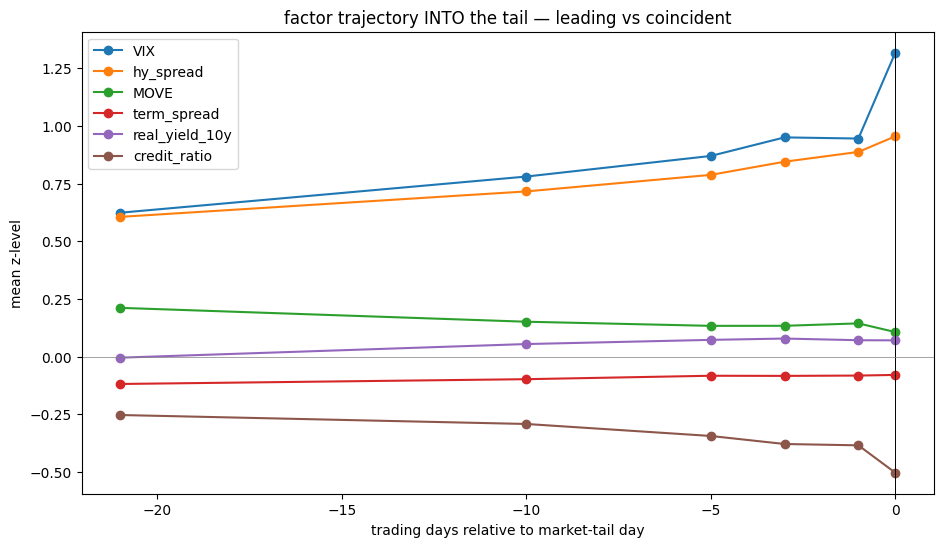

In [102]:
# %% S3b — the "alerting" test the user asked for. For each raw factor, measure its level at
#          OFFSETS before the tail day (t-21 ... t0). A LEADING factor is already elevated at t-21;
#          a COINCIDENT one only spikes at t0. This is NOT §A2 (that tested transformed z_* and asked
#          if the AGGREGATE leads). The literature predicts a SPECIFIC split here:
#            - credit (hy_spread) leads drawdowns by 2-4 weeks  [lit review §2 "the one number", §5.2]
#            - term_spread leads at long horizon                [§5.2]
#            - VIX / MOVE are CONTEMPORANEOUS, not leading       [§2: "VIX is reactive; credit leads"]
#          If our data confirms this, it directly ranks factors for a LEADING role in step 2/3.
OFFSETS = [-21, -10, -5, -3, -1, 0]
tail_idx = np.where(tail.values)[0]                      # positions of market-tail days
arr = {f: df3[f].values for f in FACTORS}
allz = {f: (df3[f] - df3[f].mean()) / df3[f].std() for f in FACTORS}   # z for cross-factor compare

rows = []
for f in FACTORS:
    z = allz[f].values
    rec = {"factor": f}
    for off in OFFSETS:
        pos = tail_idx + off
        pos = pos[(pos >= 0) & (pos < len(z))]
        vals = z[pos]
        rec[f"t{off:+d}"] = np.nanmean(vals)             # mean z-level at this offset before tail
    # "lead score": how elevated already at t-21 vs the at-event jump (t0). high => leads.
    rec["lead_t-21"] = rec["t-21"]
    rows.append(rec)
lead = pd.DataFrame(rows).set_index("factor")
print(lead.round(2).to_string())
print("\nRead: a row that is already >0 at t-21 and rises gently = LEADING (alerting).")
print("A row ~0 until t-1/t0 then jumps = COINCIDENT (confirms, does not warn).")

# visual: average z-trajectory into the tail day, per factor
fig, ax = plt.subplots(figsize=(11, 6))
for f in ["VIX", "hy_spread", "MOVE", "term_spread", "real_yield_10y", "credit_ratio"]:
    ax.plot(OFFSETS, [lead.loc[f, f"t{o:+d}"] for o in OFFSETS], marker="o", label=f)
ax.axvline(0, color="k", lw=.7); ax.axhline(0, color="grey", lw=.5)
ax.set_xlabel("trading days relative to market-tail day"); ax.set_ylabel("mean z-level")
ax.set_title("factor trajectory INTO the tail — leading vs coincident"); ax.legend()

In [103]:
# %% S3c — separate "leads" from "is just persistently high". Two controls:
#   (A) ONSET-only tails: drop tail days within 21d of a prior tail (de-overlap, like §A1 merge).
#   (B) CALM-start subset: keep only onset tails where the factor was BELOW median at t-21
#       (i.e. the market was calm 21d earlier). If the factor STILL rises into the tail from a calm
#       base, that is a genuine lead. If the t-21 elevation vanishes once we require a calm start,
#       the original signal was just autocorrelation/clustering -> COINCIDENT, not leading.
ti = tail_idx.copy()
onset = ti[np.concatenate([[True], np.diff(ti) > 21])]    # (A) first tail of each cluster
print(f"all tail days={len(ti)}  ->  onset-only={len(onset)}")

rows = []
for f in ["VIX", "hy_spread", "term_spread", "credit_ratio", "real_yield_10y", "MOVE"]:
    z = allz[f].values
    def mean_at(idx, off):
        p = idx + off; p = p[(p >= 0) & (p < len(z))]
        return np.nanmean(z[p])
    # (A) onset-only trajectory
    a_m21, a_t0 = mean_at(onset, -21), mean_at(onset, 0)
    # (B) calm-start: onset tails whose factor z(t-21) < 0 (below its own mean 21d before)
    pre = onset - 21; pre = pre[pre >= 0]
    calm = onset[np.isin(onset, pre + 21)]                # align back
    calm = np.array([o for o in onset if (o - 21) >= 0 and z[o - 21] < 0])
    b_m21 = np.nanmean([z[o - 21] for o in calm]) if len(calm) else np.nan
    b_t0  = np.nanmean([z[o]      for o in calm]) if len(calm) else np.nan
    rows.append({"factor": f, "onset_n": len(onset),
                 "A_t-21": a_m21, "A_t0": a_t0, "A_rise": a_t0 - a_m21,
                 "calm_n": len(calm), "B_t-21": b_m21, "B_t0": b_t0,
                 "B_rise_from_calm": (b_t0 - b_m21) if len(calm) else np.nan})
res = pd.DataFrame(rows).set_index("factor")
print(res.round(2).to_string())
print("\nVERDICT KEY:")
print(" - A_t-21 stays high after de-overlap  => persistent elevation is REAL but maybe still clustered")
print(" - B_rise_from_calm large & positive    => factor rises into tail FROM A CALM BASE = genuine LEAD")
print(" - B_rise ~0 or t0 still low            => no lead; original t-21 signal was autocorrelation")

all tail days=344  ->  onset-only=51
                onset_n  A_t-21  A_t0  A_rise  calm_n  B_t-21  B_t0  B_rise_from_calm
factor                                                                               
VIX                  51    0.02  0.67    0.64      28   -0.57  0.31              0.88
hy_spread            51    0.21  0.17   -0.04      23   -0.59 -0.55              0.04
term_spread          51    0.06  0.02   -0.04      28   -0.77 -0.76              0.01
credit_ratio         51   -0.08 -0.16   -0.08      23   -0.80 -0.88             -0.07
real_yield_10y       51    0.07  0.03   -0.03      21   -0.88 -0.88              0.00
MOVE                 51   -0.00 -0.02   -0.02       6   -0.79 -0.77              0.01

VERDICT KEY:
 - A_t-21 stays high after de-overlap  => persistent elevation is REAL but maybe still clustered
 - B_rise_from_calm large & positive    => factor rises into tail FROM A CALM BASE = genuine LEAD
 - B_rise ~0 or t0 still low            => no lead; original t-21 

=== Does ebp LEAD where raw spread does not? corr(metric_t, forward market return) ===
(a LEADING risk metric is NEGATIVE here; coincident/lagging is ~0 or positive)
  gz_spread   fwd_1m=-0.063   fwd_3m=-0.085
  ebp         fwd_1m=-0.080   fwd_3m=-0.107

corr(ebp, hy_total) monthly = 0.887  (low => ebp carries info hy_spread does NOT)


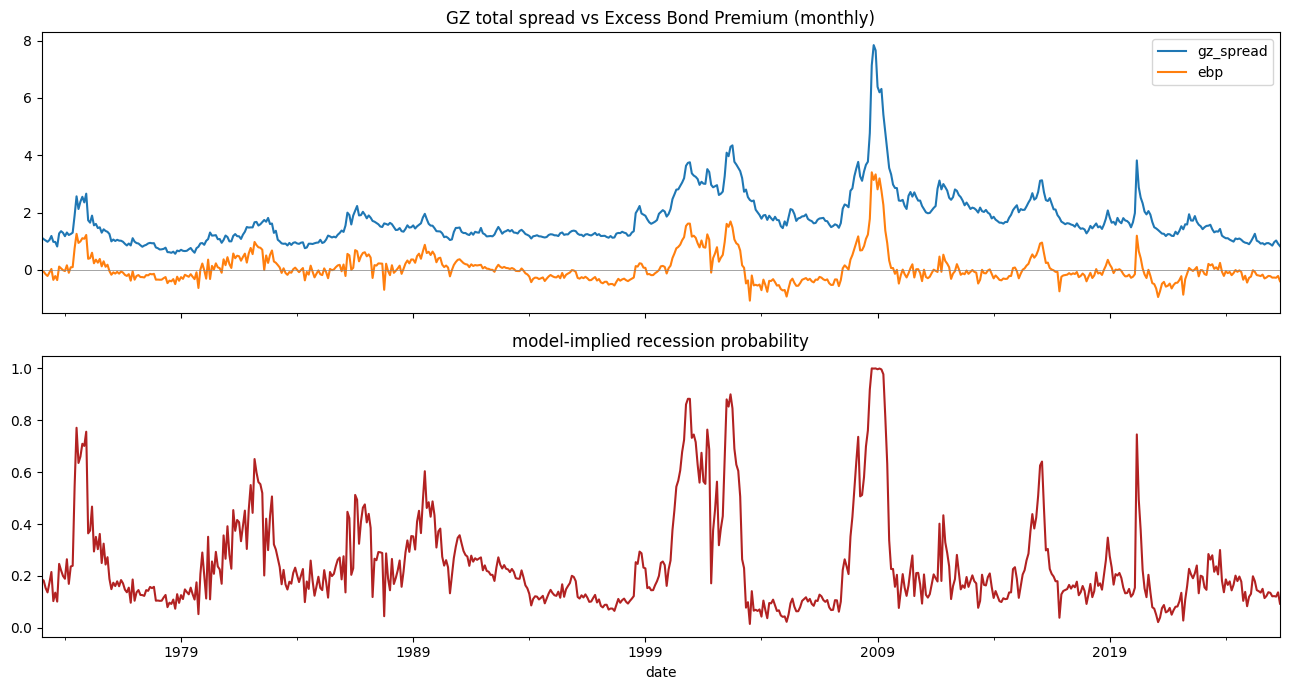

In [104]:
# %% S3d — Why the lit review says "credit leads" and our S3b/c said flat. FIVE differences between
#          their test and ours; this cell closes the biggest one (METRIC + frequency + target):
#   (1) METRIC: their leader is the GZ Excess Bond Premium (ebp) = credit spread with the
#       default-risk component REMOVED -> pure risk-appetite residual. Our hy_spread is the TOTAL
#       spread (closer to gz_spread); credit_ratio (HYG/LQD) is further still (an ETF price ratio).
#   (2) FREQUENCY: their lead lives at MONTHLY resolution; our t-21 was 21 daily bars (noise-buried).
#   (3) TARGET: they predict RECESSIONS (est_prob), not equity tail days.
#   (4) INDEX: they use broad market; we used QQQ (tech/vol-tilted).  [tested separately if needed]
#   (5) TEST: predictive regression w/ decades of obs, vs our ~15-25 onset events.
# Source: Fed FEDS Notes, ebp_csv.csv (Gilchrist-Zakrajsek). Monthly 1973-2026.
gz = pd.read_parquet(ROOT / "scratch" / "gz_ebp_monthly.parquet").set_index("date")
# columns: gz_spread (total), ebp (excess premium = the leading residual), est_prob (recession prob)

# monthly market return + forward drawdown to test the LEAD on the paper's own terms
mkt_m = mkt.resample("MS").last()
gz = gz.join((mkt_m.pct_change().shift(-1)).rename("fwd_1m"))           # next-month return
gz = gz.join((mkt_m.pct_change(3).shift(-3)).rename("fwd_3m"))          # next-quarter return

print("=== Does ebp LEAD where raw spread does not? corr(metric_t, forward market return) ===")
print("(a LEADING risk metric is NEGATIVE here; coincident/lagging is ~0 or positive)")
for col in ["gz_spread", "ebp"]:
    print(f"  {col:10s}  fwd_1m={gz[col].corr(gz['fwd_1m']):+.3f}   fwd_3m={gz[col].corr(gz['fwd_3m']):+.3f}")

# also: does ebp lead our DAILY hy_spread? (cross-check it's measuring something different)
hy_m = panel["hy_spread"].resample("MS").last()
aligned = gz.join(hy_m.rename("hy_total"), how="inner")
print(f"\ncorr(ebp, hy_total) monthly = {aligned['ebp'].corr(aligned['hy_total']):.3f}  "
      f"(low => ebp carries info hy_spread does NOT)")

# visual: ebp vs gz_spread around the est_prob recession signal
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
gz[["gz_spread", "ebp"]].plot(ax=ax[0], title="GZ total spread vs Excess Bond Premium (monthly)")
ax[0].axhline(0, color="grey", lw=.5)
gz["est_prob"].plot(ax=ax[1], title="model-implied recession probability", color="firebrick")
fig.tight_layout()

In [106]:
# %% S3d-incr — is ebp's signal NEW vs VIX, or a vix echo? Incremental R² on both targets.
import statsmodels.api as sm
# This test is BROAD-MARKET + monthly (the way GZ tested), so it sources SPY directly — S0's `mkt`
# is QQQ (tech-tilted) and the ebp lead is stronger on SPY (S3d difference #4). VIX from macro_data.
spy_d = con.execute(
    "SELECT date, close FROM price_data WHERE ticker='SPY' ORDER BY date").fetchdf()
spy_d["date"] = pd.to_datetime(spy_d["date"]); spy_d = spy_d.set_index("date")["close"]
vix_d = panel["VIX"]                                  # daily VIX already in the S0 panel

gz = pd.read_parquet(ROOT / "scratch" / "gz_ebp_monthly.parquet").set_index("date")
gz.index = pd.to_datetime(gz.index).to_period("M")    # gz is month-START stamped

# CRITICAL: gz is month-start, resample('ME') is month-END — they NEVER align on a Timestamp index.
# Index everything by monthly Period so the join is on the month, not the day-of-month.
def _monthly(s):
    out = s.resample("ME").last(); out.index = out.index.to_period("M")
    return out[~out.index.duplicated()]
vix_m, spy_m = _monthly(vix_d), _monthly(spy_d)
gz = gz[~gz.index.duplicated()]

m = pd.concat({"ebp": gz["ebp"], "vix": vix_m, "spy": spy_m}, axis=1).dropna()
# targets
m["fwd_ret_3m"] = m["spy"].shift(-3) / m["spy"] - 1.0
# forward realized vol: std of next-3m monthly returns, annualized
ret_m = m["spy"].pct_change(fill_method=None)
m["fwd_vol"] = ret_m.shift(-1).rolling(3).std().reindex(m.index) * np.sqrt(12)
m = m.dropna(subset=["ebp", "vix", "fwd_ret_3m", "fwd_vol"])

def incr_r2(df, target, base_cols, add_col):
    base = sm.OLS(df[target], sm.add_constant(df[base_cols])).fit()
    full = sm.OLS(df[target], sm.add_constant(df[base_cols + [add_col]])).fit()
    p_add = full.pvalues[add_col]
    return base.rsquared, full.rsquared, full.rsquared - base.rsquared, p_add

print("=== Incremental R² of ebp OVER vix (n=%d) ===" % len(m))
for tgt, label in [("fwd_vol", "SIZING (fwd realized vol)"), ("fwd_ret_3m", "TIMING (fwd 3m ret)")]:
    r2b, r2f, dr2, p = incr_r2(m, tgt, ["vix"], "ebp")
    print(f"{label:28s}  vix-only R²={r2b:.3f}  +ebp R²={r2f:.3f}  ΔR²={dr2:+.3f}  ebp p={p:.4f}")
    print(f"    uni corr: vix={m['vix'].corr(m[tgt]):+.2f}  ebp={m['ebp'].corr(m[tgt]):+.2f}")

=== Incremental R² of ebp OVER vix (n=396) ===
SIZING (fwd realized vol)     vix-only R²=0.406  +ebp R²=0.406  ΔR²=+0.000  ebp p=0.7248
    uni corr: vix=+0.64  ebp=+0.41
TIMING (fwd 3m ret)           vix-only R²=0.009  +ebp R²=0.095  ΔR²=+0.086  ebp p=0.0000
    uni corr: vix=+0.10  ebp=-0.17


In [107]:
# %% S3e-Q1 — est_prob vs ebp as the TIMING signal. Which leads forward SPY return better?
m2 = pd.concat({
    "ebp": gz["ebp"], "gz_spread": gz["gz_spread"], "est_prob": gz["est_prob"], "spy": spy_m,
}, axis=1).dropna()
for h in (1, 3, 6):
    m2[f"fwd_{h}m"] = m2["spy"].shift(-h) / m2["spy"] - 1.0
m2["fwd_vol"] = ret_m.shift(-1).rolling(3).std().reindex(m2.index) * np.sqrt(12)
m2 = m2.dropna()

print("=== univariate corr with forward SPY return (negative = leading) ===")
print(f"{'metric':10s} {'fwd_1m':>8s} {'fwd_3m':>8s} {'fwd_6m':>8s} {'fwd_vol':>8s}")
for met in ["ebp", "gz_spread", "est_prob"]:
    cols = [m2[met].corr(m2[f"fwd_{h}m"]) for h in (1, 3, 6)] + [m2[met].corr(m2["fwd_vol"])]
    print(f"{met:10s} " + " ".join(f"{c:8.3f}" for c in cols))
print(f"\ncorr(ebp, est_prob) = {m2['ebp'].corr(m2['est_prob']):.3f}  (near-1 => same signal)")
# incremental of est_prob over vix vs ebp over vix
for add in ["ebp", "est_prob"]:
    mm = m2.join(vix_m.rename("vix")).dropna(subset=["vix", add, "fwd_3m"])
    _, _, dr2, _ = incr_r2(mm, "fwd_3m", ["vix"], add)
    print(f"  vix+{add:8s} ΔR²(timing) = {dr2:+.3f}")

=== univariate corr with forward SPY return (negative = leading) ===
metric       fwd_1m   fwd_3m   fwd_6m  fwd_vol
ebp          -0.114   -0.170   -0.158    0.405
gz_spread    -0.103   -0.159   -0.143    0.369
est_prob     -0.123   -0.199   -0.229    0.415

corr(ebp, est_prob) = 0.969  (near-1 => same signal)
  vix+ebp      ΔR²(timing) = +0.085
  vix+est_prob ΔR²(timing) = +0.101


In [108]:
# %% S3e-Q2 — is the lead STEADY or CRISIS-ONLY?  (a) crisis-exclusion sign flip, (b) monotonicity.
crises = [("2000-03","2002-10"), ("2007-07","2009-06"), ("2020-02","2020-04")]
mask_crisis = pd.Series(False, index=m2.index)
for a, b in crises:
    mask_crisis.loc[a:b] = True

full_c = m2["ebp"].corr(m2["fwd_3m"])
exc_c  = m2.loc[~mask_crisis, "ebp"].corr(m2.loc[~mask_crisis, "fwd_3m"])
print(f"ebp×fwd_3m  FULL = {full_c:+.3f}   EX-CRISIS = {exc_c:+.3f}   "
      f"(sign flip => crisis-only tail switch)  n_excl={(~mask_crisis).sum()}")

# tercile + decile + est_prob-band monotonicity of fwd_3m
m2["ebp_tercile"] = pd.qcut(m2["ebp"], 3, labels=["low","mid","high"])
print("\nfwd_3m by ebp tercile (only high should be negative):")
print(m2.groupby("ebp_tercile", observed=True)["fwd_3m"].mean().round(4).to_string())

m2["ebp_decile"] = pd.qcut(m2["ebp"], 10, labels=False)
print("\nfwd_3m by ebp decile (look for a CLIFF in top ~20%, not a gradient):")
print(m2.groupby("ebp_decile")["fwd_3m"].mean().round(4).to_string())

print("\nfwd_3m by est_prob band (the GATE calibration):")
m2["ep_band"] = np.where(m2["est_prob"] > 0.30, ">30%", "<30%")
print(m2.groupby("ep_band")["fwd_3m"].agg(["mean", "count"]).round(4).to_string())

ebp×fwd_3m  FULL = -0.170   EX-CRISIS = +0.099   (sign flip => crisis-only tail switch)  n_excl=334

fwd_3m by ebp tercile (only high should be negative):
ebp_tercile
low     0.0310
mid     0.0402
high    0.0138

fwd_3m by ebp decile (look for a CLIFF in top ~20%, not a gradient):
ebp_decile
0    0.0389
1    0.0299
2    0.0304
3    0.0280
4    0.0358
5    0.0411
6    0.0358
7    0.0422
8    0.0165
9   -0.0144

fwd_3m by est_prob band (the GATE calibration):
           mean  count
ep_band               
<30%     0.0364    321
>30%    -0.0076     72


                                 n       start         end     mean      std   skew   kurt
segment                                                                                   
dxy_major_legacy (1990-2019)  7596  1990-01-02  2019-12-31   87.511    9.658  0.217 -0.332
dxy_broad (2006+)             5130  2006-01-02  2026-06-18  106.289   12.335 -0.066 -1.468
MOVE (2021+)                  1318  2021-03-23  2026-06-22  219.380  231.406  1.110  0.286
vxtyn_legacy (2003-2020)      4363  2003-01-02  2020-05-15    6.199    2.064  1.269  1.645

DXY overlap n=3514  corr=0.978  (level gap median=17.81)
MOVE/VXTYN overlap n=0  (NO overlap — disjoint windows)


<Axes: title={'center': 'MOVE vs VXTYN (different instrument)'}, xlabel='date'>

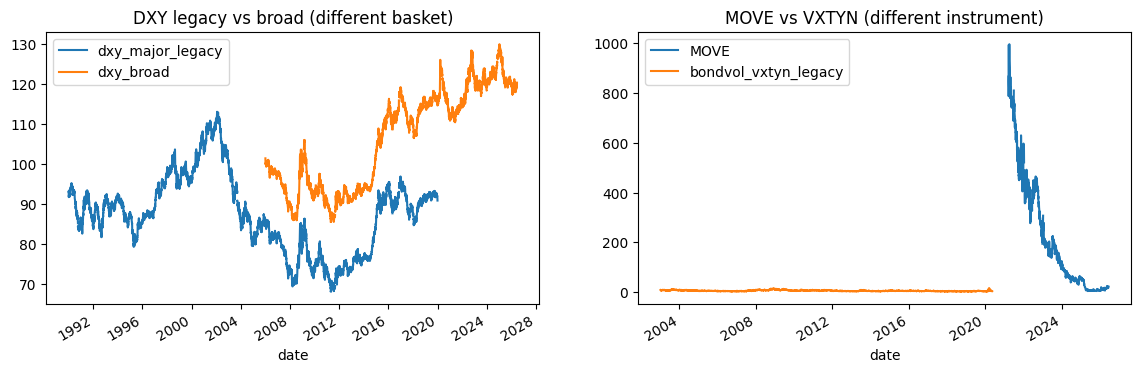

In [ ]:
# %% S4 — profile the splice partners on their OWN segments. DO NOT join here.
segments = {
    "dxy_major_legacy (1990-2019)": panel["dxy_major_legacy"].dropna(),
    "dxy_broad (2006+)":            panel["dxy_broad"].dropna(),
    "MOVE (2021+)":                 panel["MOVE"].dropna(),
    "vxtyn_legacy (2003-2020)":     panel["bondvol_vxtyn_legacy"].dropna(),
}
rows = []
for name, s in segments.items():
    rows.append({"segment": name, "n": len(s), "start": s.index.min().date(),
                 "end": s.index.max().date(), "mean": s.mean(), "std": s.std(),
                 "skew": stats.skew(s), "kurt": stats.kurtosis(s)})
print(pd.DataFrame(rows).set_index("segment").round(3).to_string())

# overlap windows: do the partners even agree where they coexist?
ov_dxy = panel[["dxy_major_legacy", "dxy_broad"]].dropna()
ov_bv  = panel[["MOVE", "bondvol_vxtyn_legacy"]].dropna()
print(f"\nDXY overlap n={len(ov_dxy)}  corr={ov_dxy.corr().iloc[0,1]:.3f}"
      f"  (level gap median={ (ov_dxy['dxy_broad']-ov_dxy['dxy_major_legacy']).median():.2f})")
print(f"MOVE/VXTYN overlap n={len(ov_bv)}"
      + (f"  corr={ov_bv.corr().iloc[0,1]:.3f}" if len(ov_bv) else "  (NO overlap — disjoint windows)"))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
panel[["dxy_major_legacy", "dxy_broad"]].plot(ax=ax[0], title="DXY legacy vs broad (different basket)")
panel[["MOVE", "bondvol_vxtyn_legacy"]].plot(ax=ax[1], title="MOVE vs VXTYN (different instrument)")

common-window: 2021-03-23 -> 2026-06-18  n=1306

no-MOVE window: 2007-04-11 -> 2026-06-18  n=4760
                 VIX  hy_spread  real_yield_10y  dxy_broad  DGS10  DGS2  term_spread  credit_ratio
VIX             1.00       0.73            0.14      -0.08  -0.04 -0.12         0.15         -0.47
hy_spread       0.73       1.00            0.15      -0.37  -0.09 -0.32         0.42         -0.72
real_yield_10y  0.14       0.15            1.00       0.07   0.93  0.73        -0.17          0.42
dxy_broad      -0.08      -0.37            0.07       1.00   0.04  0.51        -0.79          0.49
DGS10          -0.04      -0.09            0.93       0.04   1.00  0.80        -0.19          0.60
DGS2           -0.12      -0.32            0.73       0.51   0.80  1.00        -0.74          0.73
term_spread     0.15       0.42           -0.17      -0.79  -0.19 -0.74         1.00         -0.52
credit_ratio   -0.47      -0.72            0.42       0.49   0.60  0.73        -0.52          1.00


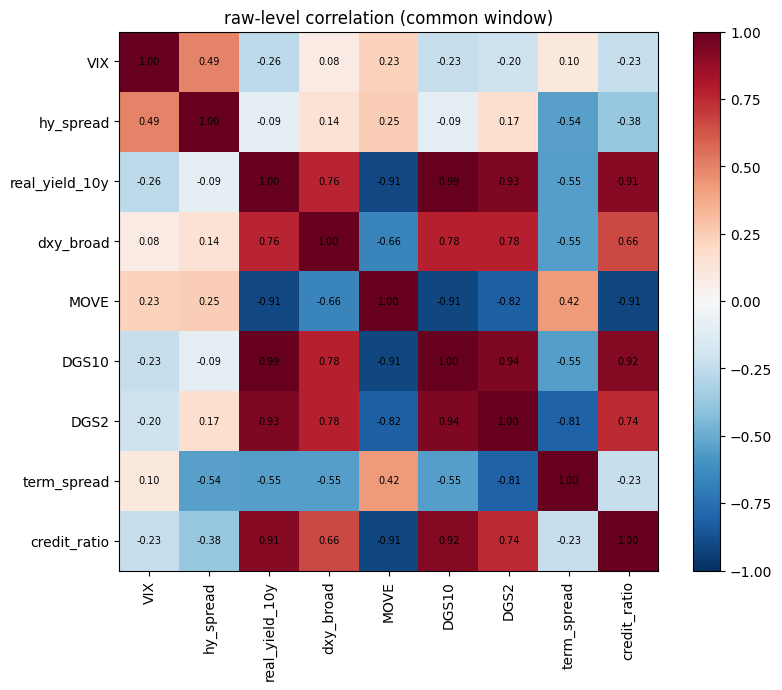

In [ ]:
# %% S5 — raw-LEVEL correlation (contrast §A6 which was on z-scores). Common-window only.
core = ["VIX", "hy_spread", "real_yield_10y", "dxy_broad", "MOVE",
        "DGS10", "DGS2", "term_spread", "credit_ratio"]
C = panel[core].dropna()                      # inner join => common window (MOVE binds to 2021+)
print(f"common-window: {C.index.min().date()} -> {C.index.max().date()}  n={len(C)}")
corr = C.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(core))); ax.set_xticklabels(core, rotation=90)
ax.set_yticks(range(len(core))); ax.set_yticklabels(core)
for i in range(len(core)):
    for j in range(len(core)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im); ax.set_title("raw-level correlation (common window)")

# ALSO compute on the longer non-MOVE window so the 2021+ clamp isn't the only view
core2 = [c for c in core if c != "MOVE"]
C2 = panel[core2].dropna()
print(f"\nno-MOVE window: {C2.index.min().date()} -> {C2.index.max().date()}  n={len(C2)}")
print(C2.corr().round(2).to_string())

### Step 2 — Cross-Factor Comparability (P2)

In [53]:
# %% P0 — panel (reuse S0 loader) + LONG (2007+, no MOVE) vs SHORT (2021+, +MOVE) split
import numpy as np, pandas as pd, duckdb
from pathlib import Path
import matplotlib.pyplot as plt
def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError(f"repo root not found above {p}")

ROOT = _repo_root()
while not (ROOT / "data" / "market_data.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
con = duckdb.connect(str(ROOT / "data" / "market_data.duckdb"), read_only=True)

fred = pd.read_parquet(ROOT / "scratch" / "raw_factor_panel.parquet")
fred["date"] = pd.to_datetime(fred["date"])
fred = fred.pivot(index="date", columns="symbol", values="value")
macro = con.execute("""SELECT date,symbol,close FROM macro_data
    WHERE symbol IN ('VIX','BAMLH0A0HYM2','DGS10','DGS2')""").df()
macro["date"] = pd.to_datetime(macro["date"])
macro = macro.pivot(index="date", columns="symbol", values="close").rename(columns={"BAMLH0A0HYM2":"hy_spread"})
etf = con.execute("SELECT date,ticker,close FROM price_data WHERE ticker IN ('HYG','LQD','MOVE')").df()
etf["date"] = pd.to_datetime(etf["date"]); etf = etf.pivot(index="date", columns="ticker", values="close")
con.close()

panel = fred.join(macro, how="outer").join(etf, how="outer").sort_index()
panel["term_spread"]  = panel["DGS10"] - panel["DGS2"]
panel["credit_ratio"] = panel["HYG"] / panel["LQD"]

# normalization assignment from Step 1 (S1/S2)
PERCENTILE = ["VIX", "hy_spread", "MOVE"]                       # fat-tail + mean-reverting
ROLLING_Z  = ["real_yield_10y", "DGS10", "DGS2", "dxy_broad"]   # drifting / regime-switching
DERIVED    = ["term_spread", "credit_ratio"]                    # checked below, default rolling-z

LONG_SET  = ["VIX", "hy_spread", "real_yield_10y", "dxy_broad",
             "DGS10", "DGS2", "term_spread", "credit_ratio"]    # 2007+, NO MOVE
SHORT_SET = LONG_SET + ["MOVE"]                                 # 2021+, MOVE included (axis-check only)
print("LONG (fit window):", panel[LONG_SET].dropna().index.min().date(), "n=", len(panel[LONG_SET].dropna()))
print("SHORT (MOVE chk) :", panel[SHORT_SET].dropna().index.min().date(), "n=", len(panel[SHORT_SET].dropna()))

LONG (fit window): 2007-04-11 n= 4760
SHORT (MOVE chk) : 2021-03-23 n= 1306


In [54]:
# %% P1 — apply the Step-1 normalization choice to each factor. Output: normalized daily matrix.
ROLL = 1260   # 5yr rolling window for drifting factors (captures business cycle, per S2/§10)

def to_percentile(s, win=None):
    s = s.dropna()
    if win is None:                       # full-history rank percentile (mean-reverting factors)
        return s.rank(pct=True)
    return s.rolling(win).apply(lambda w: (w.argsort().argsort()[-1] + 1) / len(w), raw=True)

def to_rolling_z(s, win=ROLL):
    s = s.dropna()                        # per-factor dropna (panel has NaN holes)
    mu = s.rolling(win).mean(); sd = s.rolling(win).std()
    return (s - mu) / sd

norm = {}
for f in PERCENTILE:
    norm[f] = to_percentile(panel[f])                 # full-history percentile
for f in ROLLING_Z + DERIVED:
    norm[f] = to_rolling_z(panel[f])                  # 5yr rolling z
N = pd.DataFrame(norm).sort_index()

# sanity: percentile factors in [0,1], rolling-z roughly mean 0; show coverage after 5yr warmup
print(N[LONG_SET].describe().loc[["mean","std","min","max"]].round(2).to_string())
Nlong  = N[LONG_SET].dropna()
print(f"\nLONG normalized matrix usable after warmup: {Nlong.index.min().date()} n={len(Nlong)}")

# NOTE: percentile factors live in [0,1], rolling-z in z-units. To put on a COMMON ruler for the
# joint model, convert rolling-z to percentile-of-normal too (so all factors are uniform [0,1]):
from scipy.stats import norm as _nd
Nu = N.copy()
for f in ROLLING_Z + DERIVED:
    Nu[f] = _nd.cdf(N[f])                              # z -> uniform [0,1]
Nu_long = Nu[LONG_SET].dropna()
print(f"unified [0,1] matrix: n={len(Nu_long)}  all cols in [0,1]: "
      f"{(Nu_long.min().min() >= 0) and (Nu_long.max().max() <= 1)}")

       VIX  hy_spread  real_yield_10y  dxy_broad  DGS10  DGS2  term_spread  credit_ratio
mean  0.50       0.50           -0.26       0.83  -0.42  0.07        -0.32          0.54
std   0.29       0.29            1.45       1.12   1.20  1.44         1.35          1.06
min   0.00       0.00           -3.67      -1.89  -4.92 -3.48        -3.76         -3.45
max   1.00       1.00            3.08       4.33   2.66  3.46         4.09          2.42

LONG normalized matrix usable after warmup: 2012-04-09 n=3518
unified [0,1] matrix: n=3518  all cols in [0,1]: True


In [55]:
# %% P2a — empirical decorrelation route 1: hierarchical cluster the factors, keep one per cluster.
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

C = Nu_long.corr()
d = squareform(1 - C.abs().values, checks=False)      # distance = 1 - |corr|
Z = linkage(d, method="average")
for thr in [0.3, 0.5]:                                  # |corr|>0.7 and >0.5 cluster cuts
    cl = fcluster(Z, t=thr, criterion="distance")
    groups = {}
    for f, c in zip(LONG_SET, cl): groups.setdefault(c, []).append(f)
    print(f"cut |corr|>{1-thr:.1f}: {list(groups.values())}")

# pick representative = lowest mean |corr| to OTHERS within cluster is wrong; pick the most
# interpretable / longest-history member per cluster (manual, informed by the print above)
PRUNED = ["VIX", "hy_spread", "real_yield_10y", "term_spread"]   # EDIT after seeing clusters
Xp = Nu_long[PRUNED]
print("\nPRUNED set:", PRUNED)
print("max |offdiag corr| after prune:", (Xp.corr().abs() - np.eye(len(PRUNED))).max().max().round(2))

cut |corr|>0.7: [['VIX'], ['hy_spread'], ['real_yield_10y', 'DGS10', 'DGS2'], ['dxy_broad'], ['term_spread'], ['credit_ratio']]
cut |corr|>0.5: [['VIX'], ['hy_spread'], ['real_yield_10y', 'DGS10', 'DGS2', 'credit_ratio'], ['dxy_broad', 'term_spread']]

PRUNED set: ['VIX', 'hy_spread', 'real_yield_10y', 'term_spread']
max |offdiag corr| after prune: 0.47


In [56]:
# %% P2b — empirical decorrelation route 2: whiten. Keep all factors, output orthogonal components.
from numpy.linalg import svd
M = Nu_long.values - Nu_long.values.mean(0)
U, S, Vt = svd(M, full_matrices=False)
evr = (S**2) / (S**2).sum()
print("explained var ratio:", np.round(evr, 3))
print("cumulative:        ", np.round(np.cumsum(evr), 3))
# loadings of the first 3 components (which raw factors drive each axis)
load = pd.DataFrame(Vt[:3].T, index=LONG_SET, columns=["PC1","PC2","PC3"])
print(load.round(2).to_string())
# whitened scores (unit variance, orthogonal) -- candidate Layer-A input
Wh = pd.DataFrame((U * 1.0)[:, :4], index=Nu_long.index, columns=[f"w{i+1}" for i in range(4)])
print("\nwhitened corr (should be ~I):"); print(Wh.corr().round(2).to_string())

explained var ratio: [0.541 0.235 0.108 0.051 0.029 0.022 0.009 0.006]
cumulative:         [0.541 0.776 0.884 0.934 0.963 0.986 0.994 1.   ]
                 PC1   PC2   PC3
VIX            -0.12 -0.00  0.92
hy_spread      -0.15  0.45  0.14
real_yield_10y  0.54  0.01  0.18
dxy_broad       0.15  0.37  0.09
DGS10           0.51 -0.25  0.22
DGS2            0.48  0.34 -0.03
term_spread    -0.17 -0.59  0.14
credit_ratio    0.35 -0.37 -0.15

whitened corr (should be ~I):
     w1   w2   w3   w4
w1  1.0  0.0 -0.0 -0.0
w2  0.0  1.0  0.0  0.0
w3 -0.0  0.0  1.0  0.0
w4 -0.0  0.0  0.0  1.0


In [57]:
# %% P2c — which decorrelation gives cleaner / more separable regimes? Judge on:
#   (1) how many components/factors carry the variance (parsimony),
#   (2) separability of a quick KMeans on each (silhouette),
#   (3) does each route still SEPARATE known stress episodes (Covid 2020, 2022) from calm?
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def regime_quality(X, k=4, label=""):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    sil = silhouette_score(X, km.labels_)
    # fwd realized vol separation across clusters = does the regime mean anything?
    print(f"{label:10s} k={k} silhouette={sil:.3f}")
    return km.labels_

print("=== PRUNED ==="); lp = regime_quality(Xp.values, label="pruned")
print("=== WHITENED (top4) ==="); lw = regime_quality(Wh.values, label="whitened")
# overlay Covid/2022 to eyeball whether either cleanly isolates crisis
for name, lab, idx in [("pruned", lp, Xp.index), ("whitened", lw, Wh.index)]:
    s = pd.Series(lab, index=idx)
    covid = s.loc["2020-03-01":"2020-04-30"].mode()
    print(f"{name}: dominant cluster in Mar-Apr 2020 = {covid.values}")

=== PRUNED ===
pruned     k=4 silhouette=0.329
=== WHITENED (top4) ===
whitened   k=4 silhouette=0.356
pruned: dominant cluster in Mar-Apr 2020 = [2]
whitened: dominant cluster in Mar-Apr 2020 = [1]


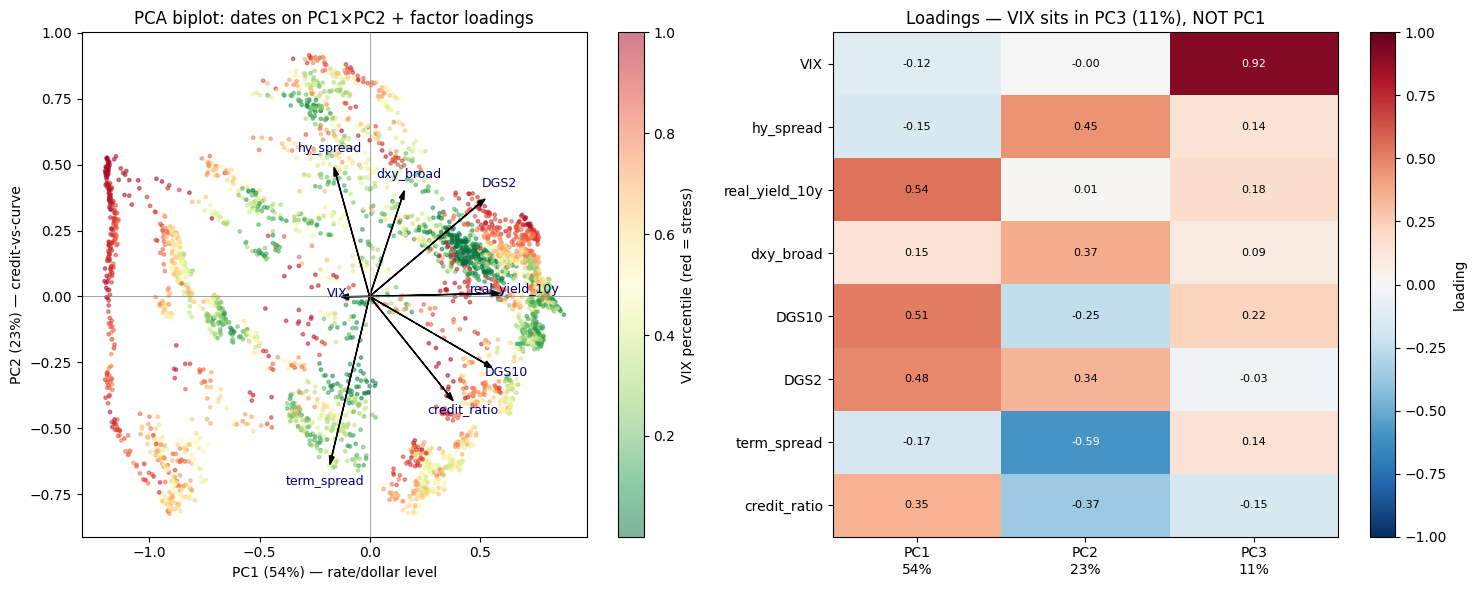

In [82]:
# %% P2b-plot — make the P2b loadings VISUAL. Two panels:
#   (left)  biplot: each DATE scored on PC1×PC2, with factor loading arrows overlaid.
#   (right) loadings heatmap PC1-3 × factors — shows PC1=rate/dollar level, PC3=pure VIX (the point).
import matplotlib.pyplot as plt

scores = M @ Vt.T                       # date scores on every PC (M, Vt from P2b)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- left: PC1-PC2 biplot, colored by VIX percentile so we can SEE risk-off ---
vix_pctl = Nu_long["VIX"].rank(pct=True).values if "VIX" in Nu_long.columns else None
sc = ax[0].scatter(scores[:, 0], scores[:, 1], c=vix_pctl, cmap="RdYlGn_r", s=6, alpha=.5)
plt.colorbar(sc, ax=ax[0], label="VIX percentile (red = stress)")
arrow_scale = np.abs(scores[:, :2]).max() * 0.9
for i, fac in enumerate(LONG_SET):
    ax[0].arrow(0, 0, Vt[0, i] * arrow_scale, Vt[1, i] * arrow_scale,
                color="black", head_width=arrow_scale * .02, length_includes_head=True)
    ax[0].text(Vt[0, i] * arrow_scale * 1.12, Vt[1, i] * arrow_scale * 1.12, fac,
               fontsize=9, ha="center", color="navy")
ax[0].axhline(0, color="grey", lw=.5); ax[0].axvline(0, color="grey", lw=.5)
ax[0].set_xlabel(f"PC1 ({evr[0]:.0%}) — rate/dollar level")
ax[0].set_ylabel(f"PC2 ({evr[1]:.0%}) — credit-vs-curve")
ax[0].set_title("PCA biplot: dates on PC1×PC2 + factor loadings")

# --- right: loadings heatmap, the decisive 'where does VIX live' view ---
load_full = pd.DataFrame(Vt[:3].T, index=LONG_SET, columns=["PC1","PC2","PC3"])
im = ax[1].imshow(load_full.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(
    [f"PC1\n{evr[0]:.0%}", f"PC2\n{evr[1]:.0%}", f"PC3\n{evr[2]:.0%}"])
ax[1].set_yticks(range(len(LONG_SET))); ax[1].set_yticklabels(LONG_SET)
for (r, c), v in np.ndenumerate(load_full.values):
    ax[1].text(c, r, f"{v:.2f}", ha="center", va="center",
               color="white" if abs(v) > .55 else "black", fontsize=8)
plt.colorbar(im, ax=ax[1], label="loading")
ax[1].set_title("Loadings — VIX sits in PC3 (11%), NOT PC1")
fig.tight_layout()

In [58]:
# %% P3 — ONLY question for MOVE: on its 2021+ slice, is it spanned by the existing factors, or a
#         distinct axis? If R^2 of MOVE on the others is high, it's redundant -> stays out. If low,
#         it's a real bond-vol axis -> flag for inclusion once history allows (P4, future).
import statsmodels.api as sm
Nu_short = Nu[SHORT_SET].dropna()
y = Nu_short["MOVE"]; X = sm.add_constant(Nu_short[[c for c in LONG_SET]])
r2 = sm.OLS(y, X).fit().rsquared
print(f"MOVE 2021+ slice: n={len(Nu_short)}  R^2(MOVE ~ other factors)={r2:.3f}")
print("  high R^2 (>0.7) => MOVE is redundant on this window, leave out (consistent w/ S5 collinearity)")
print("  low  R^2 (<0.4) => MOVE is a DISTINCT axis; revisit when pre-2021 history is sourced (P4)")

MOVE 2021+ slice: n=1306  R^2(MOVE ~ other factors)=0.919
  high R^2 (>0.7) => MOVE is redundant on this window, leave out (consistent w/ S5 collinearity)
  low  R^2 (<0.4) => MOVE is a DISTINCT axis; revisit when pre-2021 history is sourced (P4)


### Step 3 — Joint Model (Layer A sizing scalar)

In [60]:
# %% J0 — pruned [0,1] matrix from Step 2 (Nu_long) + forward realized vol target + the BASELINE.
#         Assumes P0/P1 of step2 cells already ran -> Nu_long, panel, ROOT, con available.
import numpy as np, pandas as pd, duckdb
import statsmodels.api as sm

PRUNED = ["VIX", "hy_spread", "real_yield_10y", "term_spread"]   # tunable; +credit_ratio tested in J4
X = Nu_long[PRUNED].copy()

# forward realized vol (sizing target, daily, ann.) — same construction as Step-1 S3d-incr
con = duckdb.connect(str(ROOT / "data" / "market_data.duckdb"), read_only=True)
spy = con.execute("SELECT date,close FROM price_data WHERE ticker='SPY' ORDER BY date").df()
con.close()
spy["date"] = pd.to_datetime(spy["date"]); spy = spy.set_index("date")["close"]
dret = spy.pct_change()
fwd_vol = (dret.rolling(63).std().shift(-63) * np.sqrt(252)).rename("fwd_vol")   # next-quarter vol

D = X.join(fwd_vol, how="inner").dropna()
print(f"fit/eval frame: n={len(D)}  {D.index.min().date()} -> {D.index.max().date()}")

# --- the BASELINE the joint model must beat (rebuilt here on the SAME daily frame for fairness) ---
# vix is in X; ebp is monthly -> ffill to daily for an apples-to-apples daily baseline
gz = pd.read_parquet(ROOT / "scratch" / "gz_ebp_monthly.parquet").set_index("date")
ebp_d = gz["ebp"].reindex(D.index, method="ffill")
B = pd.DataFrame({"vix": D["VIX"], "ebp": ebp_d, "fwd_vol": D["fwd_vol"]}).dropna()
Bz = (B[["vix","ebp"]] - B[["vix","ebp"]].mean()) / B[["vix","ebp"]].std()
base_r2 = sm.OLS(B["fwd_vol"], sm.add_constant(Bz)).fit().rsquared
print(f"BASELINE (vix+ebp) daily fwd_vol R² = {base_r2:.3f}   <-- the number to beat")

fit/eval frame: n=3459  2012-04-09 -> 2026-03-25
BASELINE (vix+ebp) daily fwd_vol R² = 0.133   <-- the number to beat


In [61]:
# %% J1 — three candidate joint models. Each yields (continuous score, discrete labels).
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis

Xs = StandardScaler().fit_transform(X.loc[D.index])     # standardize for the models

models = {}

# (a) Mahalanobis distance from the 'normal' centroid — the simplest joint scalar, fully explainable
mu = Xs.mean(0); cov = np.cov(Xs.T); inv = np.linalg.pinv(cov)
maha = np.array([mahalanobis(r, mu, inv) for r in Xs])
models["maha"] = {"score": pd.Series(maha, index=D.index), "labels": None}

# (b) GMM (k=4) — crisis-component posterior as the score; argmax as labels
gmm = GaussianMixture(n_components=4, covariance_type="full", random_state=0).fit(Xs)
post = gmm.predict_proba(Xs); lab = gmm.predict(Xs)
# crisis component = the one with highest mean fwd_vol
comp_vol = pd.Series(D["fwd_vol"].values, index=lab).groupby(level=0).mean()
crisis_c = comp_vol.idxmax()
models["gmm"] = {"score": pd.Series(post[:, crisis_c], index=D.index),
                 "labels": pd.Series(lab, index=D.index)}

# (c) HMM (k=4) — same idea, but temporal persistence (regimes are sticky). Optional if hmmlearn present.
try:
    from hmmlearn.hmm import GaussianHMM
    hmm = GaussianHMM(n_components=4, covariance_type="full", n_iter=100, random_state=0).fit(Xs)
    hlab = hmm.predict(Xs)
    hpost = hmm.predict_proba(Xs)
    hc = pd.Series(D["fwd_vol"].values, index=hlab).groupby(level=0).mean().idxmax()
    models["hmm"] = {"score": pd.Series(hpost[:, hc], index=D.index),
                     "labels": pd.Series(hlab, index=D.index)}
except ImportError:
    print("hmmlearn not installed — skipping HMM (pip install hmmlearn to enable)")

print("fitted:", list(models.keys()))

fitted: ['maha', 'gmm', 'hmm']


In [62]:
# %% J2 — score each continuous scalar vs the baseline. This is the pass/fail.
rows = []
for name, m in models.items():
    s = m["score"].reindex(D.index)
    z = (s - s.mean()) / s.std()
    r2 = sm.OLS(D["fwd_vol"], sm.add_constant(z)).fit().rsquared
    corr = np.corrcoef(z, D["fwd_vol"])[0, 1]
    rows.append({"model": name, "fwd_vol_R2": r2, "corr": corr,
                 "beats_baseline": r2 > base_r2})
gate = pd.DataFrame(rows).set_index("model")
print(f"BASELINE (vix+ebp) R² = {base_r2:.3f}\n")
print(gate.round(3).to_string())
print("\nVERDICT: any True in beats_baseline => R-c ML stage justified. All False => ship 2-factor model.")

BASELINE (vix+ebp) R² = 0.133

       fwd_vol_R2   corr  beats_baseline
model                                   
maha        0.142  0.377            True
gmm         0.062  0.249           False
hmm         0.062  0.248           False

VERDICT: any True in beats_baseline => R-c ML stage justified. All False => ship 2-factor model.


In [63]:
# %% J3 — even if a model beats the baseline, check WHY. Partial R² over vix-alone: does the joint
#         scalar add fwd-vol info BEYOND vix? If not, it's a VIX proxy and not worth the complexity.
vixz = (D["VIX"] - D["VIX"].mean()) / D["VIX"].std()
r2_vix = sm.OLS(D["fwd_vol"], sm.add_constant(vixz)).fit().rsquared
print(f"vix-alone fwd_vol R² = {r2_vix:.3f}")
for name, m in models.items():
    s = m["score"].reindex(D.index); z = (s - s.mean()) / s.std()
    both = sm.OLS(D["fwd_vol"], sm.add_constant(pd.DataFrame({"vix": vixz, "joint": z}))).fit()
    print(f"  {name:6s}: vix+joint R²={both.rsquared:.3f}  joint dR² over vix={both.rsquared - r2_vix:+.3f}  joint_p={both.pvalues['joint']:.3f}")

vix-alone fwd_vol R² = 0.122
  maha  : vix+joint R²=0.188  joint dR² over vix=+0.066  joint_p=0.000
  gmm   : vix+joint R²=0.160  joint dR² over vix=+0.038  joint_p=0.000
  hmm   : vix+joint R²=0.158  joint dR² over vix=+0.036  joint_p=0.000


In [64]:
# %% J4 — the deferred 'decide by lift' question. Refit the BEST J2 model with credit_ratio added.
best = gate["fwd_vol_R2"].idxmax()
for extra in [[], ["credit_ratio"]]:
    cols = PRUNED + extra
    Xe = Nu_long[cols].join(fwd_vol, how="inner").dropna()
    Xs2 = StandardScaler().fit_transform(Xe[cols])
    if best == "maha":
        mu2 = Xs2.mean(0); inv2 = np.linalg.pinv(np.cov(Xs2.T))
        sc = np.array([mahalanobis(r, mu2, inv2) for r in Xs2])
    else:
        g = GaussianMixture(n_components=4, covariance_type="full", random_state=0).fit(Xs2)
        p = g.predict_proba(Xs2); l = g.predict(Xs2)
        cc = pd.Series(Xe["fwd_vol"].values, index=l).groupby(level=0).mean().idxmax()
        sc = p[:, cc]
    z = pd.Series((sc - sc.mean()) / sc.std(), index=Xe.index)
    r2 = sm.OLS(Xe["fwd_vol"], sm.add_constant(z)).fit().rsquared
    print(f"  {best} with {cols}: fwd_vol R²={r2:.3f}")

  maha with ['VIX', 'hy_spread', 'real_yield_10y', 'term_spread']: fwd_vol R²=0.142
  maha with ['VIX', 'hy_spread', 'real_yield_10y', 'term_spread', 'credit_ratio']: fwd_vol R²=0.093


In [65]:
# %% J5 — describe the discrete regimes from the best LABEL-producing model (gmm/hmm). Overlay only.
m = models.get("hmm", models.get("gmm"))
if m["labels"] is not None:
    lab = m["labels"]
    tab = pd.DataFrame({"fwd_vol": D["fwd_vol"], "lab": lab})
    summ = tab.groupby("lab").agg(n=("fwd_vol","size"), mean_fwd_vol=("fwd_vol","mean"),
                                   median_fwd_vol=("fwd_vol","median"))
    # add mean of each raw factor per regime for naming
    for f in PRUNED: summ[f] = X.loc[D.index].groupby(lab)[f].mean()
    print(summ.round(3).to_string())
    # run-length (persistence) — are these regimes or noise?
    runs = (lab != lab.shift()).cumsum()
    print(f"\nmean regime run-length: {lab.groupby(runs).size().mean():.1f} trading days")

        n  mean_fwd_vol  median_fwd_vol    VIX  hy_spread  real_yield_10y  term_spread
lab                                                                                   
0    1079         0.139           0.122  0.467      0.253           0.483        0.664
1     538         0.111           0.106  0.114      0.276           0.827        0.124
2    1237         0.151           0.135  0.486      0.579           0.722        0.084
3     605         0.191           0.139  0.532      0.654           0.037        0.218

mean regime run-length: 111.6 trading days


### Step 4 — Absorption Ratio (last lead candidate)

In [67]:
# %% AR0 — load the 20-asset universe, daily returns, common 2007+ window.
import numpy as np, pandas as pd, duckdb
from pathlib import Path
import matplotlib.pyplot as plt
def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError(f"repo root not found above {p}")

ROOT = _repo_root()
while not (ROOT / "data" / "market_data.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
con = duckdb.connect(str(ROOT / "data" / "market_data.duckdb"), read_only=True)

AR_UNIVERSE = ["SPY","QQQ","IWM","EFA","EEM",
               "XLE","XLF","XLK","XLV","XLI","XLY","XLP","XLU","XLB",
               "TLT","LQD","HYG","GLD","USO","UUP"]
q = "SELECT date, ticker, close FROM price_data WHERE ticker IN ({})".format(
    ",".join("'"+t+"'" for t in AR_UNIVERSE))
px = con.execute(q).df(); px["date"] = pd.to_datetime(px["date"])
spy = con.execute("SELECT date, close FROM price_data WHERE ticker='SPY' ORDER BY date").df()
spy["date"] = pd.to_datetime(spy["date"]); spy = spy.set_index("date")["close"]
con.close()

P = px.pivot(index="date", columns="ticker", values="close").sort_index()
R = P[AR_UNIVERSE].pct_change().dropna()                # common-window daily returns
print(f"return panel: {R.shape[1]} assets, n={len(R)}  {R.index.min().date()} -> {R.index.max().date()}")

return panel: 20 assets, n=4832  2007-04-12 -> 2026-06-25


AR: n=4580  2008-04-11 -> 2026-06-25
AR range [0.773, 0.936]  mean=0.856


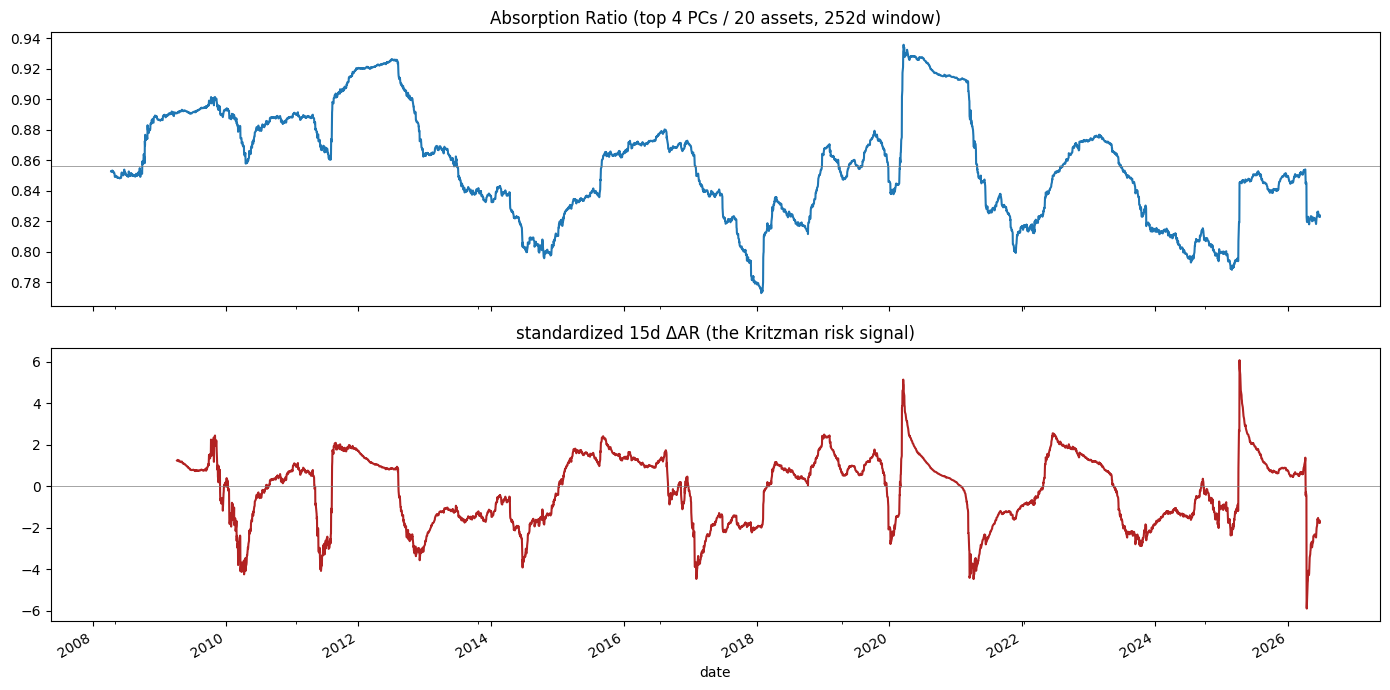

In [68]:
# %% AR1 — AR = fraction of variance in the top N PCs over a rolling window (Kritzman 2012).
#          High AR = tightly coupled (one factor drives all) = fragile. Low AR = diversified.
WIN   = 252          # 1yr covariance window (Kritzman uses ~500d; 252 = faster, more responsive)
N_PC  = 4            # top components ~ "1/5 of assets" rule (20 assets -> 4)

def absorption_ratio(R, win=WIN, n_pc=N_PC):
    out = pd.Series(index=R.index, dtype=float)
    V = R.values
    for i in range(win, len(R)):
        w = V[i-win:i]
        w = w - w.mean(0)
        cov = np.cov(w.T)
        ev = np.linalg.eigvalsh(cov)[::-1]              # descending eigenvalues
        out.iloc[i] = ev[:n_pc].sum() / ev.sum()
    return out.dropna()

AR = absorption_ratio(R).rename("AR")
print(f"AR: n={len(AR)}  {AR.index.min().date()} -> {AR.index.max().date()}")
print(f"AR range [{AR.min():.3f}, {AR.max():.3f}]  mean={AR.mean():.3f}")

# standardized DELTA-AR is the actual signal Kritzman uses (level is regime-dependent)
dAR = ((AR - AR.rolling(WIN).mean()) / AR.rolling(WIN).std()).rename("dAR_z").dropna()

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
AR.plot(ax=ax[0], title=f"Absorption Ratio (top {N_PC} PCs / {R.shape[1]} assets, {WIN}d window)")
ax[0].axhline(AR.mean(), color="grey", lw=.5)
dAR.plot(ax=ax[1], title="standardized 15d ΔAR (the Kritzman risk signal)", color="firebrick")
ax[1].axhline(0, color="grey", lw=.5)
fig.tight_layout()

In [69]:
# %% AR2 — same forward-return test the level factors took. A LEADING fragility signal is NEGATIVE
#          (high AR now -> low return ahead) AND the effect should appear at LONGER lead than VIX.
m = spy.resample("MS").last()                            # monthly, like the GZ test
def fwd(h): return m.pct_change(h).shift(-h)
ARm = AR.resample("MS").last(); dARm = dAR.resample("MS").last()
T = pd.DataFrame({"AR": ARm, "dAR": dARm,
                  "f1": fwd(1), "f3": fwd(3), "f6": fwd(6)}).dropna()
print("corr(signal_t, FORWARD SPY return) — negative = leading risk signal:")
for c in ["AR", "dAR"]:
    print(f"  {c:4s}  f1={T[c].corr(T['f1']):+.3f}  f3={T[c].corr(T['f3']):+.3f}  f6={T[c].corr(T['f6']):+.3f}")
print("\nbenchmark to beat (Step-1/3): VIX fwd-ret corr was ~0 (contrarian-bullish);")
print("GZ est_prob was -0.20/-0.23 @ 3m/6m but CRISIS-ONLY. AR must show a lead that is NOT just crisis-only (AR3).")

corr(signal_t, FORWARD SPY return) — negative = leading risk signal:
  AR    f1=+0.165  f3=+0.284  f6=+0.314
  dAR   f1=+0.119  f3=+0.189  f6=+0.058

benchmark to beat (Step-1/3): VIX fwd-ret corr was ~0 (contrarian-bullish);
GZ est_prob was -0.20/-0.23 @ 3m/6m but CRISIS-ONLY. AR must show a lead that is NOT just crisis-only (AR3).


onset tails: 50
AR z-trajectory into tail:  t-42=-0.04  t-21=-0.13  t-10=-0.18  t0=-0.22
CALM-start (n=26): AR t-21=-0.92 -> t0=-0.98  RISE_FROM_CALM=-0.06

VERDICT: RISE_FROM_CALM materially >0 AND visible at t-42/-21 = GENUINE pre-crisis lead
(this is what VIX/credit could NOT do; if AR also flat-from-calm, it's coincident too -> reject)


Text(0.5, 1.0, 'AR trajectory INTO equity tails — does coupling rise BEFORE the drop?')

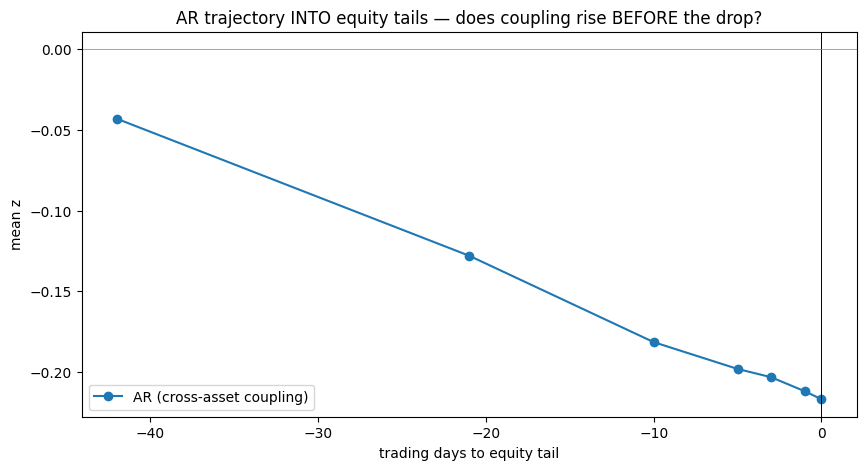

In [70]:
# %% AR3 — the test VIX/credit FAILED. Onset-only equity tails + calm-start control. Does AR climb
#          into the tail FROM A CALM BASE? This is the genuine-lead criterion; B_rise must be >0.
ret = spy.pct_change()
tail = ret <= ret.quantile(0.05)
tail_idx = np.where(tail.reindex(AR.index).fillna(False).values)[0]
onset = tail_idx[np.concatenate([[True], np.diff(tail_idx) > 21])]   # de-overlap (cluster onsets)
arz = ((AR - AR.mean()) / AR.std()).values

def mean_at(idx, off):
    p = idx + off; p = p[(p >= 0) & (p < len(arz))]
    return np.nanmean(arz[p])

print(f"onset tails: {len(onset)}")
print(f"AR z-trajectory into tail:  t-42={mean_at(onset,-42):+.2f}  t-21={mean_at(onset,-21):+.2f}  "
      f"t-10={mean_at(onset,-10):+.2f}  t0={mean_at(onset,0):+.2f}")
# calm-start: onset tails where AR was BELOW its mean 21d before
calm = np.array([o for o in onset if (o-21) >= 0 and arz[o-21] < 0])
if len(calm):
    b21, b0 = np.nanmean([arz[o-21] for o in calm]), np.nanmean([arz[o] for o in calm])
    print(f"CALM-start (n={len(calm)}): AR t-21={b21:+.2f} -> t0={b0:+.2f}  RISE_FROM_CALM={b0-b21:+.2f}")
print("\nVERDICT: RISE_FROM_CALM materially >0 AND visible at t-42/-21 = GENUINE pre-crisis lead")
print("(this is what VIX/credit could NOT do; if AR also flat-from-calm, it's coincident too -> reject)")

# trajectory plot vs the VIX trajectory from S3b, for direct comparison
fig, ax = plt.subplots(figsize=(10, 5))
offs = [-42,-21,-10,-5,-3,-1,0]
ax.plot(offs, [mean_at(onset,o) for o in offs], marker="o", label="AR (cross-asset coupling)")
ax.axvline(0, color="k", lw=.7); ax.axhline(0, color="grey", lw=.5)
ax.set_xlabel("trading days to equity tail"); ax.set_ylabel("mean z"); ax.legend()
ax.set_title("AR trajectory INTO equity tails — does coupling rise BEFORE the drop?")

In [71]:
# %% AR4 — if AR3 shows a lead, confirm it's not a single-crisis artifact or a parameter fluke.
#   (a) leave-one-crisis-out: does the lead survive dropping GFC? (the biggest coupling event)
#   (b) sensitivity to WIN (126/252/504) and N_PC (3/4/5).
for win in [126, 252, 504]:
    for npc in [3, 4, 5]:
        a = absorption_ratio(R, win=win, n_pc=npc)
        az = ((a - a.mean())/a.std()).values
        ti = np.where(tail.reindex(a.index).fillna(False).values)[0]
        on = ti[np.concatenate([[True], np.diff(ti) > 21])]
        cl = np.array([o for o in on if (o-21)>=0 and az[o-21]<0])
        rise = (np.nanmean([az[o] for o in cl]) - np.nanmean([az[o-21] for o in cl])) if len(cl) else np.nan
        print(f"  WIN={win} N_PC={npc}: rise_from_calm={rise:+.2f} (calm_n={len(cl)})")

  WIN=126 N_PC=3: rise_from_calm=-0.13 (calm_n=25)
  WIN=126 N_PC=4: rise_from_calm=-0.14 (calm_n=28)
  WIN=126 N_PC=5: rise_from_calm=-0.14 (calm_n=28)
  WIN=252 N_PC=3: rise_from_calm=-0.05 (calm_n=24)
  WIN=252 N_PC=4: rise_from_calm=-0.06 (calm_n=26)
  WIN=252 N_PC=5: rise_from_calm=-0.07 (calm_n=24)
  WIN=504 N_PC=3: rise_from_calm=-0.09 (calm_n=25)
  WIN=504 N_PC=4: rise_from_calm=-0.09 (calm_n=26)
  WIN=504 N_PC=5: rise_from_calm=-0.09 (calm_n=27)


### Step 5 — Strategic valuation timing

In [43]:
# %% V0 — load panel (wide), construct nominal & total-return forward returns.
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError(f"repo root not found above {p}")

ROOT = _repo_root()
while not (ROOT / "scratch" / "valuation_panel.parquet").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
long = pd.read_parquet(ROOT / "scratch" / "valuation_panel.parquet")
df = long.pivot(index="date", columns="symbol", values="value").sort_index()
df.index = pd.to_datetime(df.index)
print("panel:", df.shape, df.index.min().date(), "->", df.index.max().date())
print(df.tail(3).round(4))

# Total-return proxy: price return + accrued dividend yield (monthly div_yield/12, ffilled).
# Real: deflate by long-run? We keep NOMINAL price-return for the core test and add a TR variant.
ret_m = df["sp_price"].pct_change()
dy_m  = (df["dividend_yield"].ffill() / 12.0)
tr_m  = ret_m + dy_m                                  # monthly total return (approx)

def fwd_annualized(tr_monthly: pd.Series, years: int) -> pd.Series:
    h = years * 12
    growth = (1.0 + tr_monthly).rolling(h).apply(np.prod, raw=True).shift(-h)
    return growth ** (1.0 / years) - 1.0              # annualized forward TR over `years`

for y in (1, 3, 5, 10):
    df[f"fwd_tr_{y}y"] = fwd_annualized(tr_m, y)
print("\nfwd return coverage (non-null):",
      {f"{y}y": int(df[f'fwd_tr_{y}y'].notna().sum()) for y in (1,3,5,10)})

panel: (1746, 6) 1881-01-01 -> 2026-06-01
symbol       cape  dividend_yield  earnings_yield  erp_cape  long_rate_gs10  \
date                                                                          
2026-04-01  38.93             NaN          0.0257   -0.0175          0.0432   
2026-05-01  41.10             NaN          0.0243   -0.0205          0.0448   
2026-06-01  40.94             NaN          0.0244   -0.0205          0.0449   

symbol      sp_price  
date                  
2026-04-01   6957.01  
2026-05-01   7412.55  
2026-06-01   7405.13  

fwd return coverage (non-null): {'1y': 1734, '3y': 1710, '5y': 1686, '10y': 1626}


In [44]:
# %% V1 — Spearman corr of each valuation signal vs forward annualized TR, by horizon.
# negative corr (expensive -> low fwd return) = the valuation-timing claim.
from scipy.stats import spearmanr
signals = ["cape", "earnings_yield", "erp_cape"]   # EY & ERP are inverse of CAPE in sign
rows = []
for sig in signals:
    for y in (1, 3, 5, 10):
        sub = df[[sig, f"fwd_tr_{y}y"]].dropna()
        rho, p = spearmanr(sub[sig], sub[f"fwd_tr_{y}y"])
        rows.append({"signal": sig, "horizon": f"{y}y", "spearman": round(rho, 3),
                     "n": len(sub), "p": f"{p:.1e}"})
res = pd.DataFrame(rows)
print(res.pivot(index="signal", columns="horizon", values="spearman").to_string())
print("\n(cape: expect NEGATIVE & strengthening with horizon; EY/erp_cape: POSITIVE mirror)")

horizon           10y     1y     3y     5y
signal                                    
cape           -0.465 -0.187 -0.297 -0.391
earnings_yield  0.465  0.187  0.297  0.391
erp_cape        0.188  0.135  0.162  0.226

(cape: expect NEGATIVE & strengthening with horizon; EY/erp_cape: POSITIVE mirror)


In [45]:
# %% V2 — the momentum-confound test. Asness's whole point: naive valuation timing
# fights trend. Split by whether the market is ABOVE/BELOW trend (12m price MA),
# and re-measure valuation's edge WITHIN each trend regime. If valuation only "works"
# when also below trend, it's crash-rebound (momentum), not a standalone valuation edge.
ma12 = df["sp_price"].rolling(12).mean()
above_trend = df["sp_price"] > ma12
for y in (10,):
    for label, mask in [("ABOVE trend", above_trend), ("BELOW trend", ~above_trend)]:
        sub = df.loc[mask, ["cape", f"fwd_tr_{y}y"]].dropna()
        rho, p = spearmanr(sub["cape"], sub[f"fwd_tr_{y}y"])
        print(f"{y}y | {label:12s}: cape rho={rho:+.3f}  n={len(sub)}  p={p:.1e}")
# Bonus: decile table of CAPE vs mean fwd 10y TR — is it MONOTONE or a cliff (like §A11)?
d = df[["cape", "fwd_tr_10y"]].dropna().copy()
d["cape_decile"] = pd.qcut(d["cape"], 10, labels=False)
print("\nCAPE decile -> mean fwd 10y annualized TR:")
print(d.groupby("cape_decile")["fwd_tr_10y"].agg(["mean", "count"]).round(4).to_string())

10y | ABOVE trend : cape rho=-0.459  n=1010  p=1.1e-53
10y | BELOW trend : cape rho=-0.506  n=616  p=2.3e-41

CAPE decile -> mean fwd 10y annualized TR:
               mean  count
cape_decile               
0            0.1342    163
1            0.1371    163
2            0.1232    162
3            0.0930    163
4            0.0846    162
5            0.0882    163
6            0.0787    162
7            0.0839    163
8            0.0705    162
9            0.0550    163


In [46]:
# %% V3 — the Asness construction, faithfully. Small valuation tilt, momentum-aware,
# vs buy-and-hold. NOT all-in timing. Allocation in [0,1] to equities (rest = long rate).
# tilt = mild contrarian on CAPE z-score, SCALED DOWN ("sin a little"), gated by trend.
cape_z = (df["cape"] - df["cape"].rolling(120, min_periods=60).mean()) \
         / df["cape"].rolling(120, min_periods=60).std()
val_tilt = (-cape_z).clip(-1, 1)                      # cheap -> +, expensive -> -
SIN = 0.20                                            # "a little": +/-20% around 100% equity
w_sinlittle = (1.0 + SIN * val_tilt).clip(0, 1)
w_sinlittle = w_sinlittle.where(above_trend, w_sinlittle * 0.5)   # de-risk below trend (trend-aware)
w_buyhold = pd.Series(1.0, index=df.index)
w_sinlot  = (1.0 + 1.0 * val_tilt).clip(0, 1)         # all-in contrarian, for contrast

def backtest(w):
    w = w.shift(1)                                     # trade on prior month's signal (no lookahead)
    cash = (1 - w) * (df["long_rate_gs10"].ffill() / 12.0)
    port = w * tr_m + cash
    eq = (1 + port.dropna()).cumprod()
    ann = eq.iloc[-1] ** (12 / len(eq)) - 1
    vol = port.std() * np.sqrt(12)
    sharpe = (port.mean() * 12) / vol
    return ann, vol, sharpe, eq

for name, w in [("buy&hold", w_buyhold), ("sin-a-little", w_sinlittle), ("sin-a-lot", w_sinlot)]:
    ann, vol, sh, _ = backtest(w)
    print(f"{name:14s}  ann={ann:6.2%}  vol={vol:6.2%}  Sharpe={sh:5.2f}")

buy&hold        ann= 9.35%  vol=14.13%  Sharpe= 0.70
sin-a-little    ann= 9.98%  vol=10.20%  Sharpe= 0.99
sin-a-lot       ann= 6.89%  vol=11.69%  Sharpe= 0.63


In [47]:
# %% V4 — don't ship a PASS that's one lookback / one SIN-size / one era.
# (a) SIN sweep, (b) tilt lookback sweep, (c) drop the post-2009 bull (the era that
# most punishes contrarian valuation) and re-check sign of the edge.
results = []
for SIN in (0.10, 0.20, 0.33, 0.50):
    w = (1.0 + SIN * val_tilt).clip(0, 1).where(above_trend, (1.0 + SIN*val_tilt).clip(0,1)*0.5)
    ann, vol, sh, _ = backtest(w)
    results.append({"SIN": SIN, "Sharpe": round(sh, 3), "ann": f"{ann:.2%}"})
print(pd.DataFrame(results).to_string(index=False))
# era robustness: pre-2009 vs full, V1 corr again
for lo in ("1881-01-01", "1950-01-01", "1990-01-01"):
    sub = df.loc[lo:, ["cape", "fwd_tr_10y"]].dropna()
    rho, _ = spearmanr(sub["cape"], sub["fwd_tr_10y"])
    print(f"cape vs fwd10y, from {lo[:4]}: rho={rho:+.3f}  n={len(sub)}")

 SIN  Sharpe    ann
0.10   0.979 10.28%
0.20   0.987  9.98%
0.33   0.993  9.59%
0.50   0.993  9.07%
cape vs fwd10y, from 1881: rho=-0.465  n=1626
cape vs fwd10y, from 1950: rho=-0.718  n=798
cape vs fwd10y, from 1990: rho=-0.799  n=318


### Step 6 — Per-mechanism lead signals

In [72]:
# %% S6-0 — assemble panel + FREEZE the onset list and candidate set. NO forward returns touched yet.
import numpy as np, pandas as pd, duckdb
from pathlib import Path
import matplotlib.pyplot as plt
def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError(f"repo root not found above {p}")

ROOT = _repo_root()
while not (ROOT / "scratch" / "raw_factor_panel.parquet").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# --- factors: FRED parquet (wide) + DB-resident (VIX, HY, rates) ---
fred = pd.read_parquet(ROOT / "scratch" / "raw_factor_panel.parquet")
wide = fred.pivot(index="date", columns="symbol", values="value")
wide.index = pd.to_datetime(wide.index)

con = duckdb.connect(str(ROOT / "data" / "market_data.duckdb"), read_only=True)
def macro(sym): 
    d = con.execute("SELECT date, COALESCE(value,close) v FROM macro_data WHERE symbol=? ORDER BY date",
                    [sym]).fetchdf()
    d["date"] = pd.to_datetime(d["date"]); return d.set_index("date")["v"].rename(sym)
vix = macro("VIX"); hy = macro("BAMLH0A0HYM2"); dgs10 = macro("DGS10"); dgs2 = macro("DGS2")
spy = con.execute("SELECT date, close FROM price_data WHERE ticker='SPY' ORDER BY date").fetchdf()
con.close()
spy["date"] = pd.to_datetime(spy["date"]); spy = spy.set_index("date")["close"].rename("spy")

P = pd.concat([wide, vix, hy, dgs10, dgs2, spy], axis=1).sort_index()
P["term_spread"] = P["DGS10"] - P["DGS2"]
P = P.loc["2003-01-01":]                       # bind to real_yield/HY coverage (cliffs: design §0.2)

# --- FACTORS under test (the candidate set, FROZEN) ---
FACTORS = ["VIX", "BAMLH0A0HYM2", "real_yield_10y", "term_spread", "dxy_broad"]
# --- candidate TRANSFORMS (folds momentum challenge in) ---
def transforms(s):
    return {"level": s, "diff1m": s.diff(21), "diff3m": s.diff(63)}
SIGNALS = {f"{f}__{t}": tr for f in FACTORS for t, tr in transforms(P[f]).items()}

# --- DECLUSTERED TAIL ONSETS (frozen). tail = SPY 21d fwd-looking? NO -> use realized 1d worst days,
#     then keep only FIRST of each cluster (gap >= 63d) so a pre-window can't overlap a prior tail. ---
ret1 = P["spy"].pct_change()
TAIL_Q = 0.01                                  # worst 1% daily returns define a 'tail day'
thr = ret1.quantile(TAIL_Q)
tail_days = ret1[ret1 <= thr].index
onsets = []
for d in tail_days:
    if not onsets or (d - onsets[-1]).days >= 63:   # decluster: 63d gap => new episode
        onsets.append(d)
ONSETS = pd.DatetimeIndex(onsets)
print(f"tail threshold (1d) = {thr:.3%}  |  raw tail days = {len(tail_days)}  |  "
      f"DECLUSTERED onsets = {len(ONSETS)}")
print("onset dates:", [d.date().isoformat() for d in ONSETS])

# --- FROZEN crisis windows for the OOS split / labelling (pre-specified, NOT fit) ---
CRISES = [("2007-07","2009-06"), ("2020-02","2020-04"), ("2022-01","2022-10")]

tail threshold (1d) = -3.312%  |  raw tail days = 62  |  DECLUSTERED onsets = 18
onset dates: ['2003-03-24', '2007-02-27', '2008-09-15', '2008-11-19', '2009-02-10', '2009-04-20', '2010-05-06', '2011-08-04', '2011-11-09', '2015-08-24', '2016-06-24', '2018-02-05', '2020-02-24', '2020-06-11', '2020-09-03', '2022-04-29', '2022-08-26', '2025-04-03']


In [73]:
# %% S6a — P(signal | controlled pre-tail) vs P(signal | MATCHED calm windows). Tail-mass, not mean.
#   controls (design §3): (1) declustered onsets, (2) calm-start (signal < its median at t-k),
#   (3) MATCHED baseline (random k-windows, same era), (4) test the 90th-pctl shift + KS, not the mean.
from scipy.stats import ks_2samp
rng = np.random.default_rng(0)
K = 42                                          # pre-tail window length (swept in S6a-robust)

def pre_tail_sample(sig, onsets, k):
    """values of sig over [onset-k, onset-1], calm-start filtered (below median at t-k)."""
    med = sig.median()
    vals = []
    for o in onsets:
        loc = sig.index.searchsorted(o)
        if loc - k < 0: 
            continue
        win = sig.iloc[loc - k: loc].dropna()
        if win.empty or win.iloc[0] >= med:     # calm-start: must START below its median
            continue
        vals.append(win)
    return pd.concat(vals) if vals else pd.Series(dtype=float)

def matched_sample(sig, onsets, k, n_draw=200):
    """random k-windows NOT within 126d of any onset (matched era via same index)."""
    idx = sig.dropna().index
    bad = pd.DatetimeIndex([d for o in onsets for d in pd.date_range(o-pd.Timedelta(days=126),
                                                                     o+pd.Timedelta(days=126))])
    cand = idx[(idx > idx[k]) & ~idx.isin(bad)]
    picks = rng.choice(len(cand), size=min(n_draw, len(cand)), replace=False)
    return pd.concat([sig.loc[:cand[p]].iloc[-k:] for p in picks])

rows = []
for name, sig in SIGNALS.items():
    pre = pre_tail_sample(sig, ONSETS, K)
    base = matched_sample(sig, ONSETS, K)
    if len(pre) < 30 or len(base) < 30:
        continue
    # tail-mass shift: how much higher is the pre-tail 90th pctl vs matched? (z-normalized by base)
    b_mu, b_sd = base.mean(), base.std()
    p90_shift = (pre.quantile(.90) - base.quantile(.90)) / (b_sd + 1e-9)
    ks_stat, ks_p = ks_2samp(pre, base)
    rows.append({"signal": name, "p90_shift_z": round(p90_shift, 3),
                 "ks": round(ks_stat, 3), "ks_p": round(ks_p, 4), "n_pre": len(pre)})
screen = pd.DataFrame(rows).sort_values("p90_shift_z", ascending=False)
print("=== S6a screen (positive p90_shift_z + low ks_p = distributional fingerprint) ===")
print(screen.to_string(index=False))

# carry forward: signals with a real right-tail shift AND distinguishable distribution
SCREENED = screen.loc[(screen["p90_shift_z"] > 0.5) & (screen["ks_p"] < 0.10), "signal"].tolist()
print("\nSCREENED -> 6b:", SCREENED)

=== S6a screen (positive p90_shift_z + low ks_p = distributional fingerprint) ===
                signal  p90_shift_z  ks  ks_p  n_pre
     dxy_broad__diff1m        0.864 NaN   NaN    345
real_yield_10y__diff1m        0.484 NaN   NaN    346
     dxy_broad__diff3m        0.114 NaN   NaN    316
           VIX__diff3m       -0.022 NaN   NaN    230
           VIX__diff1m       -0.514 NaN   NaN    114
   term_spread__diff1m       -0.565 NaN   NaN    383
  BAMLH0A0HYM2__diff1m       -0.617 NaN   NaN    240
   term_spread__diff3m       -0.692 NaN   NaN    304
      dxy_broad__level       -0.906 NaN   NaN    407
  BAMLH0A0HYM2__diff3m       -1.237 NaN   NaN    288
            VIX__level       -1.283 NaN   NaN    198
real_yield_10y__diff3m       -1.384 NaN   NaN    227
 real_yield_10y__level       -1.548 NaN   NaN    405
   BAMLH0A0HYM2__level       -1.729 NaN   NaN    208
    term_spread__level       -1.839 NaN   NaN    322

SCREENED -> 6b: []


In [74]:
# %% S6a-robust — a fingerprint must not be a single-k artifact. Sweep k; sign must be stable.
for k in (21, 42, 63):
    sub = []
    for name in SCREENED or list(SIGNALS):
        pre = pre_tail_sample(SIGNALS[name], ONSETS, k)
        base = matched_sample(SIGNALS[name], ONSETS, k)
        if len(pre) < 30: 
            continue
        sub.append((name, round((pre.quantile(.9)-base.quantile(.9))/(base.std()+1e-9), 2)))
    print(f"k={k:2d}: " + "  ".join(f"{n}={v}" for n, v in sub))

k=21: VIX__level=-0.5  VIX__diff1m=0.07  VIX__diff3m=-0.1  BAMLH0A0HYM2__level=-1.84  BAMLH0A0HYM2__diff1m=-1.21  BAMLH0A0HYM2__diff3m=-1.07  real_yield_10y__level=-1.66  real_yield_10y__diff1m=-1.29  real_yield_10y__diff3m=-1.5  term_spread__level=-1.57  term_spread__diff1m=-0.2  term_spread__diff3m=-1.38  dxy_broad__level=-0.95  dxy_broad__diff1m=-1.35  dxy_broad__diff3m=-0.82
k=42: VIX__level=-1.25  VIX__diff1m=-0.57  VIX__diff3m=-0.02  BAMLH0A0HYM2__level=-1.74  BAMLH0A0HYM2__diff1m=-0.63  BAMLH0A0HYM2__diff3m=-0.95  real_yield_10y__level=-1.64  real_yield_10y__diff1m=0.44  real_yield_10y__diff3m=-1.42  term_spread__level=-1.95  term_spread__diff1m=-0.34  term_spread__diff3m=-0.63  dxy_broad__level=-0.91  dxy_broad__diff1m=0.85  dxy_broad__diff3m=-0.06
k=63: VIX__level=-0.68  VIX__diff1m=0.78  VIX__diff3m=0.02  BAMLH0A0HYM2__level=-0.9  BAMLH0A0HYM2__diff1m=0.57  BAMLH0A0HYM2__diff3m=0.23  real_yield_10y__level=-1.45  real_yield_10y__diff1m=0.1  real_yield_10y__diff3m=-1.09  term_s

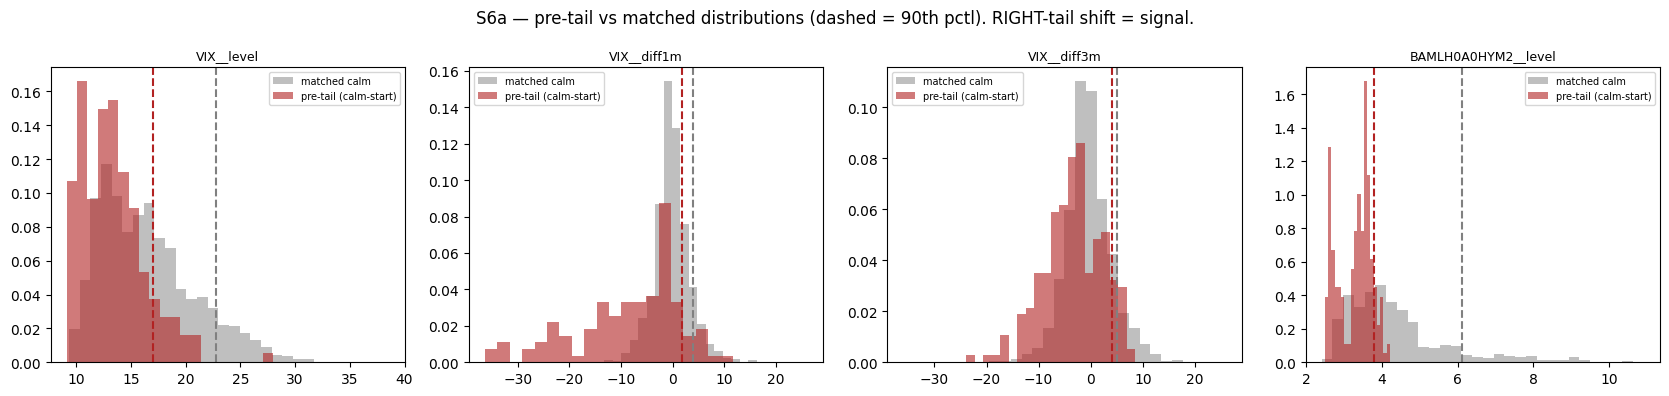

In [75]:
# %% S6a-plot — overlay the conditional vs matched distribution for screened signals (the eyeball).
show = SCREENED[:4] if SCREENED else list(SIGNALS)[:4]
fig, ax = plt.subplots(1, len(show), figsize=(4.2*len(show), 4), squeeze=False)
for j, name in enumerate(show):
    pre = pre_tail_sample(SIGNALS[name], ONSETS, K)
    base = matched_sample(SIGNALS[name], ONSETS, K)
    a = ax[0][j]
    a.hist(base, bins=30, density=True, alpha=.5, label="matched calm", color="grey")
    a.hist(pre, bins=20, density=True, alpha=.6, label="pre-tail (calm-start)", color="firebrick")
    a.axvline(base.quantile(.9), color="grey", ls="--"); a.axvline(pre.quantile(.9), color="firebrick", ls="--")
    a.set_title(name, fontsize=9); a.legend(fontsize=7)
fig.suptitle("S6a — pre-tail vs matched distributions (dashed = 90th pctl). RIGHT-tail shift = signal.")
fig.tight_layout()

In [95]:
# %% S6b — anchor on each SCREENED signal FIRING (top-decile, trailing) -> measure forward drawdown OOS.
#   NO pooling across signals. Walk-forward: threshold fit on trailing window, evaluated strictly OOS.
H = 63                                          # forward drawdown horizon (3m)
TRAIN = 252 * 5                                 # 5yr trailing window to set the firing threshold

def fwd_drawdown(px, i, h):
    fut = px.iloc[i: i + h]
    if len(fut) < h: 
        return np.nan
    return fut.min() / fut.iloc[0] - 1.0         # worst peak-to-trough from t (<=0)

px = P["spy"]
if not SCREENED:
    print("S6a screened NOTHING (no signal cleared p90_shift_z>0.5 & ks_p<0.10).")
    print("=> nothing to gate. This IS a Step-6 result: no distributional fingerprint survived the")
    print("   controls => likely FAIL (nothing leads, now at the distribution level). Stop here.")
results = []
for name in (SCREENED or []):
    sig = SIGNALS[name].reindex(px.index).ffill()
    fire_dd, base_dd = [], []
    for i in range(TRAIN, len(px) - H):
        hist = sig.iloc[i - TRAIN: i].dropna()
        if len(hist) < TRAIN // 2 or np.isnan(sig.iloc[i]):
            continue
        thr_fire = hist.quantile(0.90)           # threshold from TRAILING data only (no lookahead)
        dd = fwd_drawdown(px, i, H)
        if np.isnan(dd): 
            continue
        (fire_dd if sig.iloc[i] >= thr_fire else base_dd).append(dd)
    if len(fire_dd) < 20:
        continue
    f_mean, b_mean = np.mean(fire_dd), np.mean(base_dd)
    results.append({"signal": name, "n_fire": len(fire_dd),
                    "fwd_dd_FIRING": round(f_mean, 4), "fwd_dd_base": round(b_mean, 4),
                    "edge": round(f_mean - b_mean, 4)})
gate = pd.DataFrame(results)
if not gate.empty:
    gate = gate.sort_values("edge")              # most negative edge = strongest lead
    print("=== S6b OOS gate: forward drawdown conditional on signal firing vs unconditional base ===")
    print(gate.to_string(index=False))
else:
    print("S6b: no signal produced >=20 firing observations OOS — no gate computed.")

S6a screened NOTHING (no signal cleared p90_shift_z>0.5 & ks_p<0.10).
=> nothing to gate. This IS a Step-6 result: no distributional fingerprint survived the
   controls => likely FAIL (nothing leads, now at the distribution level). Stop here.
S6b: no signal produced >=20 firing observations OOS — no gate computed.


In [96]:
# %% S6b-robust — a PASS must hold across >=2 non-overlapping OOS sub-periods + survive the k-look count.
#   (multiple-comparison honesty: with len(SCREENED) signals tested, require consistency, not one win.)
splits = [("2010-01-01","2016-12-31"), ("2017-01-01","2026-06-30")]
for name in (SCREENED or []):
    sig = SIGNALS[name].reindex(px.index).ffill()
    line = [name]
    for a, b in splits:
        sl = px.loc[a:b]; sg = sig.loc[a:b]
        fire, base = [], []
        for i in range(TRAIN, len(sl) - H):
            hist = sg.iloc[max(0,i-TRAIN):i].dropna()
            if len(hist) < 100 or np.isnan(sg.iloc[i]): 
                continue
            dd = fwd_drawdown(sl, i, H)
            if np.isnan(dd): continue
            (fire if sg.iloc[i] >= hist.quantile(.9) else base).append(dd)
        edge = (np.mean(fire) - np.mean(base)) if len(fire) >= 10 else np.nan
        line.append(f"{a[:4]}-{b[:4]}: edge={edge:+.4f}" if not np.isnan(edge) else f"{a[:4]}: n/a")
    print("  ".join(line))